In [1]:
# ── Cell 1: Mount Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PBMC

All imports successful.
Dataset  : PBMC
Classes  : ['B', 'Mono']
Methods  : ['SynCellNet', 'SynCellNet+Copula', 'scGAN', 'scVI']

Loading PBMC data...
  real         B: (1186, 1600)
  real         Mono: (1186, 1600)
  SynCellNet   B: (1186, 1600)
  SynCellNet   Mono: (1186, 1600)
  SynCellNet+Copula B: (1186, 1600)
  SynCellNet+Copula Mono: (1186, 1600)
  scGAN        B: (1186, 1600)
  scGAN        Mono: (1186, 1600)
  scVI         B: (1186, 1600)
  scVI         Mono: (1186, 1600)

GROUP 1: Gene-level Distribution
  SynCellNet   B: mean_corr=0.9854  var_corr=0.7729  cv_corr=0.0116  det_corr=0.6519  KS=0.5901
  SynCellNet   Mono: mean_corr=0.9931  var_corr=0.9274  cv_corr=0.1143  det_corr=0.6799  KS=0.5525
  SynCellNet+Copula B: mean_corr=0.9994  var_corr=0.9714  cv_corr=0.6777  det_corr=0.9980  KS=0.0081
  SynCellNet+Copula Mono: mean_corr=0.9998  var_corr=0.9919  cv_corr=0.5930  det_corr=0.9979  KS=0.0113
  scGAN        B: mean_corr=0.9988  var_corr=0.9445  cv_corr=0.8407  det_corr=0.

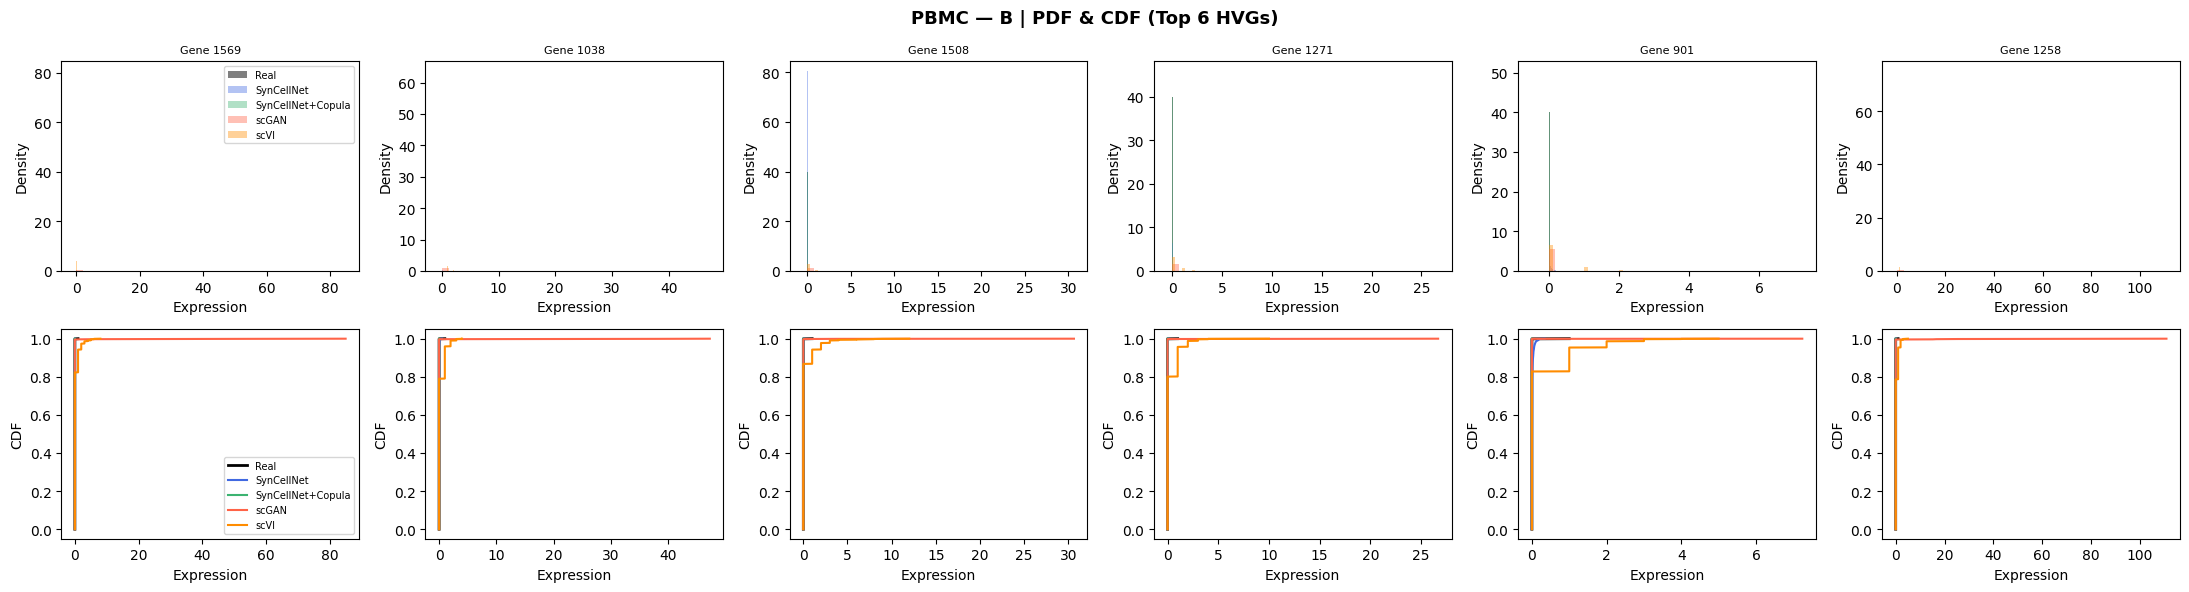

  Saved: pdf_cdf_PBMC_B.png


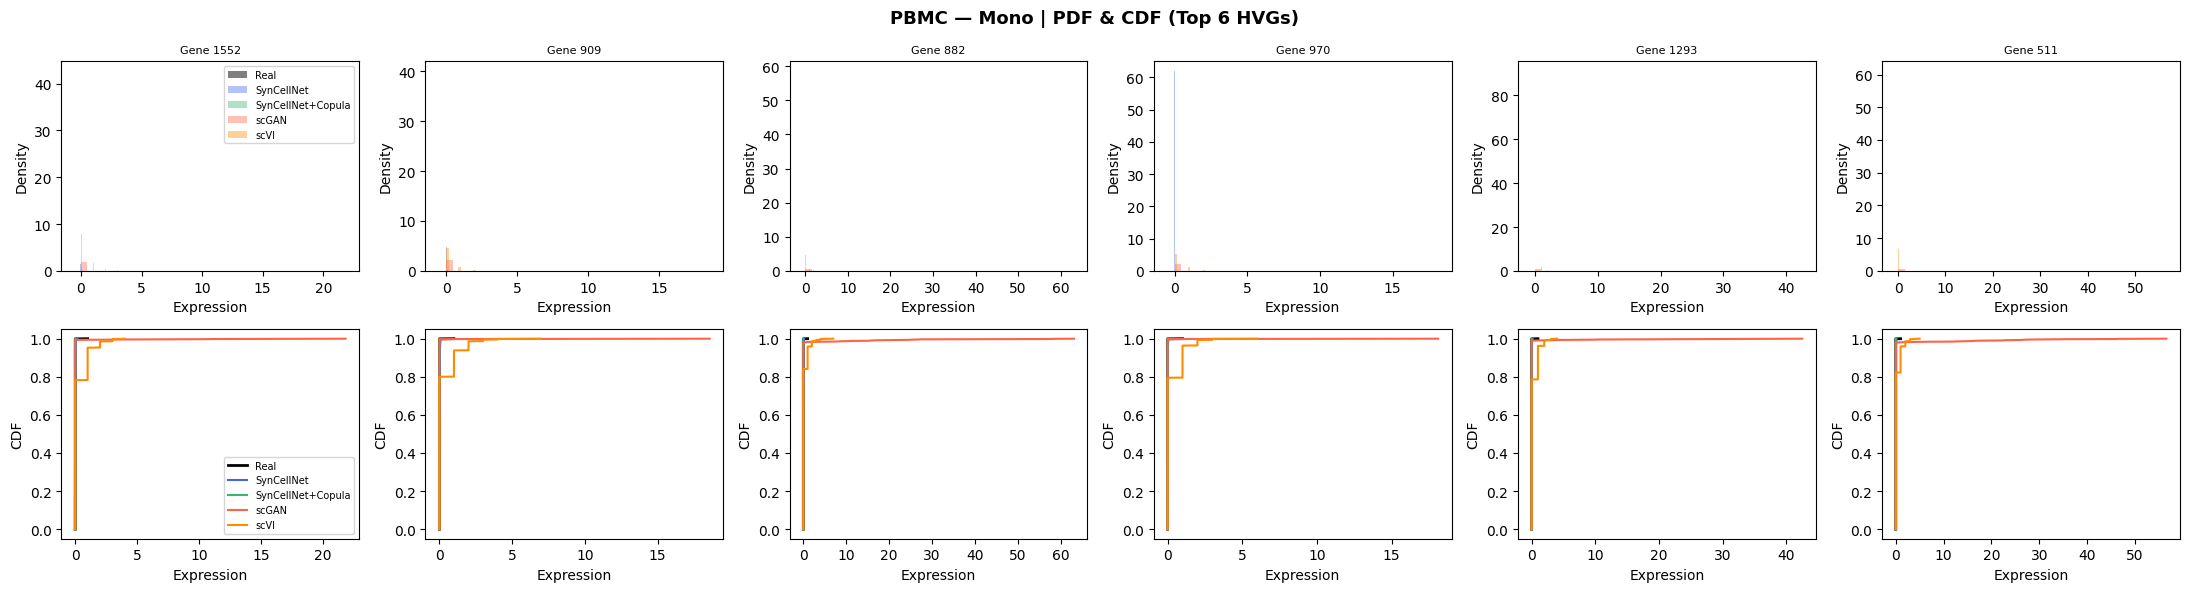

  Saved: pdf_cdf_PBMC_Mono.png

GROUP 8: Visualization — PCA, t-SNE, UMAP
  Combined matrix: (11860, 1600)
  NaN after cleaning: 0  |  Inf: 0
  Running PCA...
  PCA variance explained (PC1+PC2): 28.7%
  Running t-SNE...
  Running UMAP...


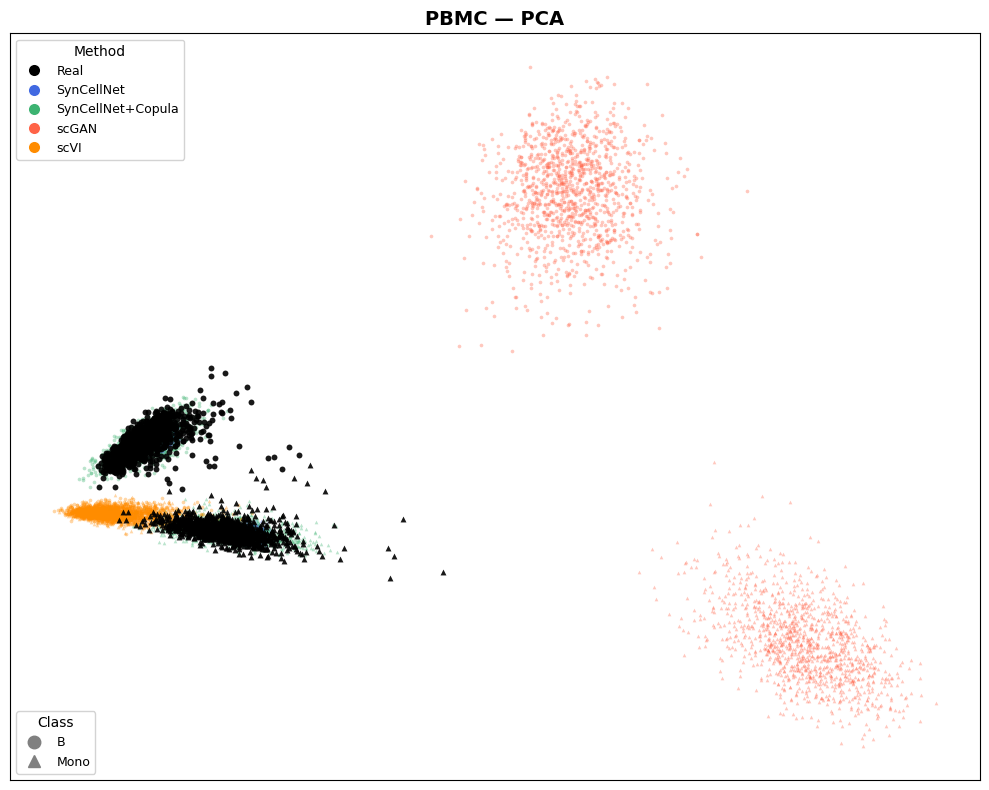

  Saved: pca_PBMC.png


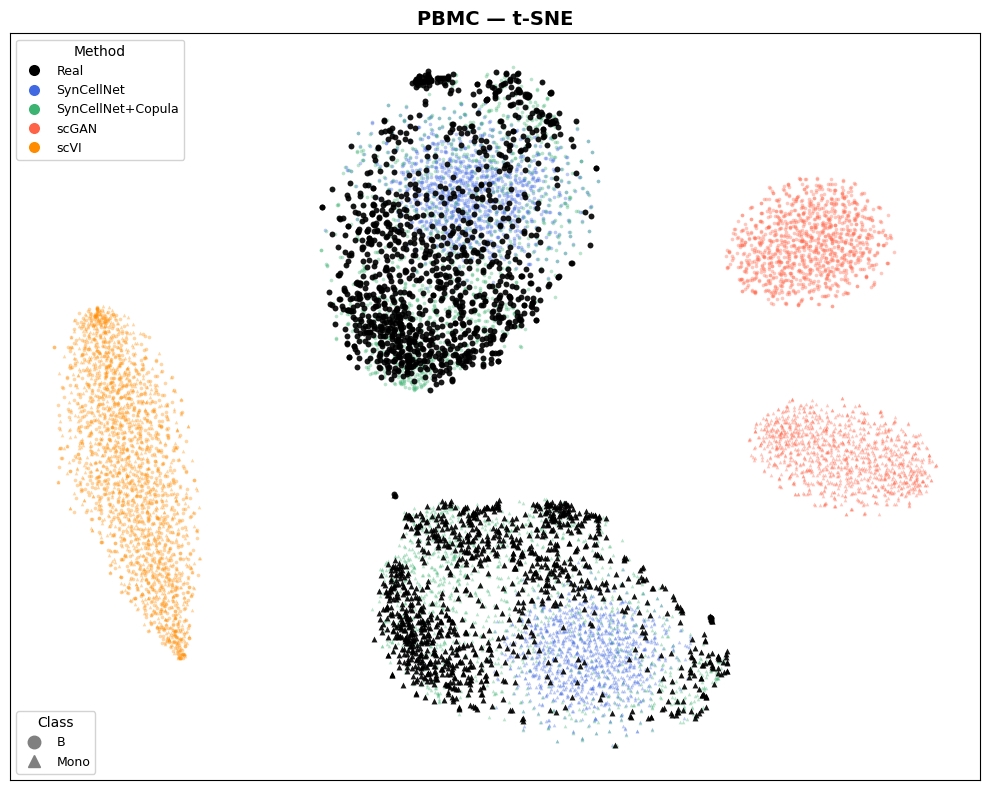

  Saved: tsne_PBMC.png


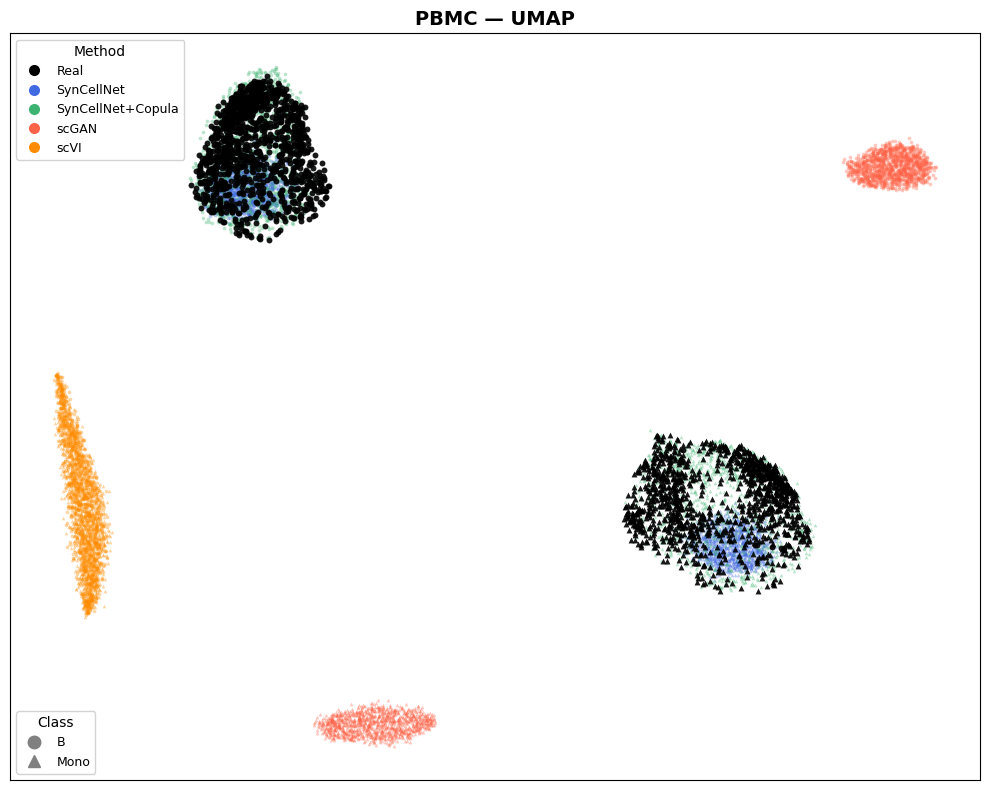

  Saved: umap_PBMC.png

  Group 8 complete.

SUMMARY RESULTS TABLE
Saved to Drive: /content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/metrics_results_PBMC.csv
           Method Class  mean_corr  var_corr  cv_corr  det_corr frz_gene_corr  avg_KS lib_size_KS frz_cell_KS  cell_det_KS  cell_dist_KS  knn_occur_KS  ldf_KS  mean_var_corr_diff  mean_frz_corr_diff lib_frz_corr_diff  gene_gene_corr gene_gene_flag  marker_corr marker_flag  cell_cell_corr cell_cell_flag  avg_Wasserstein  avg_KDE_overlap      MMD  RF_AUC  pve_real  pve_synth  pve_diff  silhouette_real  silhouette_synth  silhouette_diff  n_DE_synth  DE_overlap  DE_precision  DE_recall  DE_F1
       SynCellNet     B     0.9854    0.7729   0.0116    0.6519           N/A  0.5901         N/A         N/A       1.0000         0.592         0.216   0.284              0.1123              0.7282               N/A         -0.0028             ok       0.0199          ok          0.0543             ok           0.1427           0.8

In [ ]:
# ============================================================
# Metrics Pipeline — scRNA-seq Synthetic Data Evaluation
# Google Colab | Python
# ============================================================

# ── Cell 1: Install ──────────────────────────────────────────
# !pip install -q umap-learn scikit-learn scipy seaborn matplotlib

# ── Cell 2: Imports ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance, spearmanr
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import umap
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

# ── Cell 3: Configuration ────────────────────────────────────
DATASET = 'PBMC'   # 'PBMC' or 'PDO'

BASE = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work'

PATHS = {
    'PBMC': {
        'real': {
            'B':    BASE + '/Dataset/Real PBMC dataset/b_Class_dataset.csv',
            'Mono': BASE + '/Dataset/Real PBMC dataset/mono_Class_dataset.csv',
        },
        'SynCellNet': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/new_recovered_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/new_recovered_mono_expression.csv',
        },
        'SynCellNet+Copula': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/copula_recovered_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/copula_recovered_mono_expression.csv',
        },
        'scGAN': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/scGAN/PBMC/scgan_synthetic_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/scGAN/PBMC/scgan_synthetic_mono_expression.csv',
        },
        'scVI': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/scVI/PBMC/scvi_synthetic_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/scVI/PBMC/scvi_synthetic_mono_expression.csv',
        },
    },
    'PDO': {
        'real': {
            'Stem': BASE + '/Dataset/Real PDO/3. Stem_High_Raw_Finalized.csv',
            'Diff': BASE + '/Dataset/Real PDO/3. Differential_Low_Raw_Finalized.csv',
        },
        'SynCellNet': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/new_recovered_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/new_recovered_low_expression.csv',
        },
        'SynCellNet+Copula': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/copula_recovered_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/copula_recovered_low_expression.csv',
        },
        'scGAN': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/scGAN/PDO/scgan_synthetic_stem_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/scGAN/PDO/scgan_synthetic_diff_low_expression.csv',
        },
        'scVI': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/scVI/PDO/scvi_synthetic_stem_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/scVI/PDO/scvi_synthetic_diff_low_expression.csv',
        },
    }
}

# Methods that skip library-size based metrics
SKIP_LIBSIZE = {'SynCellNet', 'scGAN'}
# Methods that skip fraction-zero metrics
SKIP_ZEROS   = {'SynCellNet'}

METHODS  = ['SynCellNet', 'SynCellNet+Copula', 'scGAN', 'scVI']
CLASSES  = list(PATHS[DATASET]['real'].keys())
SEED     = 42

print(f'Dataset  : {DATASET}')
print(f'Classes  : {CLASSES}')
print(f'Methods  : {METHODS}')

# ── Cell 4: Load Data ─────────────────────────────────────────
def load_csv(path):
    return pd.read_csv(path, header=None).values.astype(np.float32)

def align_genes(A, B):
    """Trim both arrays to same gene count (handles scGAN PDO 1593 vs 1600)."""
    n = min(A.shape[1], B.shape[1])
    return A[:, :n], B[:, :n]

data = {}
print(f'\nLoading {DATASET} data...')
for split in ['real'] + METHODS:
    data[split] = {}
    for cls in CLASSES:
        data[split][cls] = load_csv(PATHS[DATASET][split][cls])
        print(f'  {split:12s} {cls}: {data[split][cls].shape}')

# ── Cell 5: Utility Functions ─────────────────────────────────
def log1p_norm(X):
    return np.log1p(X)

def top_hvg_indices(X, n=500):
    """Return indices of top n highly variable genes by CV."""
    means = X.mean(axis=0)
    stds  = X.std(axis=0)
    cv    = np.where(means > 0, stds / means, 0)
    return np.argsort(cv)[::-1][:n]

def marker_gene_indices(X_class0, X_class1, n=30):
    """Top n DE genes by fold change between two classes."""
    eps = 1e-8
    fc  = np.abs(np.log2(X_class0.mean(0) + eps) - np.log2(X_class1.mean(0) + eps))
    return np.argsort(fc)[::-1][:n]

def to_pca(real, synth, n_pcs=50, seed=SEED):
    """
    Log1p + clip negatives, fit PCA on pooled data, return (r_pca, s_pca).
    Safe for SynCellNet floats (negative values clipped to 0 before log1p).
    """
    log_r = np.nan_to_num(np.log1p(np.clip(real,  0, None)), nan=0., posinf=0., neginf=0.)
    log_s = np.nan_to_num(np.log1p(np.clip(synth, 0, None)), nan=0., posinf=0., neginf=0.)
    n_comp = min(n_pcs, log_r.shape[1], log_r.shape[0] - 1, log_s.shape[0] - 1)
    pca    = PCA(n_components=n_comp, random_state=seed)
    pca.fit(np.vstack([log_r, log_s]))
    return pca.transform(log_r), pca.transform(log_s)

# ── Cell 6: Group 1 — Gene-level Distribution ─────────────────
print('\n' + '='*60)
print('GROUP 1: Gene-level Distribution')
print('='*60)

g1_results = {}

for method in METHODS:
    g1_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        mean_r = real.mean(0);  mean_s = synth.mean(0)
        var_r  = real.var(0);   var_s  = synth.var(0)
        eps    = 1e-8
        cv_r   = np.where(mean_r > 0, real.std(0)/mean_r, 0)
        cv_s   = np.where(mean_s > 0, synth.std(0)/mean_s, 0)
        det_r  = (real > 0).mean(0);  det_s = (synth > 0).mean(0)
        frz_r  = (real == 0).mean(0); frz_s = (synth == 0).mean(0)

        ks_mean  = np.mean([ks_2samp(real[:,g], synth[:,g]).statistic
                            for g in range(real.shape[1])])
        r_mean, _   = stats.pearsonr(mean_r, mean_s)
        r_var,  _   = stats.pearsonr(var_r,  var_s)
        r_cv,   _   = stats.pearsonr(cv_r,   cv_s)
        r_det,  _   = stats.pearsonr(det_r,  det_s)

        if method in SKIP_ZEROS:
            r_frz = np.nan
        else:
            r_frz, _ = stats.pearsonr(frz_r, frz_s)

        g1_results[method][cls] = {
            'mean_corr'    : round(r_mean, 4),
            'var_corr'     : round(r_var,  4),
            'cv_corr'      : round(r_cv,   4),
            'det_corr'     : round(r_det,  4),
            'frz_gene_corr': round(r_frz, 4) if not np.isnan(r_frz) else 'N/A',
            'avg_KS'       : round(ks_mean, 4),
        }
        print(f'  {method:12s} {cls}: mean_corr={r_mean:.4f}  var_corr={r_var:.4f}  '
              f'cv_corr={r_cv:.4f}  det_corr={r_det:.4f}  KS={ks_mean:.4f}')

# ── Cell 7: Group 2 — Cell-level Distribution ─────────────────
# Includes the 3 metrics required by Crowell et al. that were previously missing:
#   • cell_dist_KS  — KS distance between mean-kNN-distance distributions (PCA space)
#   • knn_occur_KS  — KS distance between kNN occurrence-count distributions
#   • ldf_KS        — KS distance between Local Density Factor distributions
# ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('GROUP 2: Cell-level Distribution')
print('='*60)

K_NEIGHBORS = 10   # k for all kNN-based cell metrics
N_SAMPLE_CELL = 500  # max cells to subsample for expensive cell metrics

def _subsample(X, n, seed=SEED):
    np.random.seed(seed)
    idx = np.random.choice(len(X), min(n, len(X)), replace=False)
    return X[idx]

def compute_cell_dist_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between distributions of mean Euclidean distance to k nearest
    neighbours in PCA space.  Captures whether the local neighbourhood
    density of the synthetic cells matches the real data.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def mean_knn_dist(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        dists, _ = nbrs.kneighbors(X)
        return dists[:, 1:].mean(axis=1)   # exclude self (col 0)

    return ks_2samp(mean_knn_dist(r_sub, k), mean_knn_dist(s_sub, k)).statistic


def compute_knn_occur_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between kNN occurrence-count distributions.
    Counts how many times each cell is selected as a nearest neighbour.
    Real data typically has a heavy-tailed distribution (a few 'hub' cells
    are very popular neighbours).  Uniform occurrence → artificial structure.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def knn_counts(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        _, indices = nbrs.kneighbors(X)
        counts = np.bincount(indices[:, 1:].ravel(), minlength=len(X))
        return counts.astype(float)

    return ks_2samp(knn_counts(r_sub, k), knn_counts(s_sub, k)).statistic


def compute_ldf_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between Local Density Factor (LDF) distributions.
    LDF_i = (mean dist of cell i to its k neighbours)
            / (mean of [mean dist of each neighbour to ITS k neighbours])
    LDF > 1 → cell is in a sparser region than its neighbours (outlier).
    LDF < 1 → denser region.
    Mirrors the ldfDiff metric from CellMixS (Lütge et al. 2021) used in
    the Crowell et al. benchmark.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def ldf(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        dists, indices = nbrs.kneighbors(X)
        avg_d = dists[:, 1:].mean(axis=1)          # avg dist to k neighbours
        # avg dist of each neighbour to ITS k neighbours
        neigh_avg_d = np.array([
            avg_d[indices[i, 1:]].mean() for i in range(len(X))
        ])
        return avg_d / (neigh_avg_d + 1e-10)

    return ks_2samp(ldf(r_sub, k), ldf(s_sub, k)).statistic


g2_results = {}

for method in METHODS:
    g2_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        # ── Original cell-level metrics ───────────────────────
        lib_r  = real.sum(1);  lib_s  = synth.sum(1)
        frz_r  = (real == 0).mean(1); frz_s  = (synth == 0).mean(1)
        det_r  = (real > 0).mean(1);  det_s  = (synth > 0).mean(1)

        if method in SKIP_LIBSIZE:
            ks_lib = np.nan
            r_lib  = np.nan
        else:
            ks_lib = ks_2samp(lib_r, lib_s).statistic
            r_lib, _ = stats.pearsonr(
                np.histogram(lib_r, bins=50)[0].astype(float),
                np.histogram(lib_s, bins=50)[0].astype(float))

        if method in SKIP_ZEROS:
            ks_frz = np.nan
        else:
            ks_frz = ks_2samp(frz_r, frz_s).statistic

        ks_det = ks_2samp(det_r, det_s).statistic

        # ── NEW: PCA-based cell-level metrics (Crowell et al.) ─
        r_pca, s_pca = to_pca(real, synth, n_pcs=50)

        cell_dist_ks = compute_cell_dist_ks(r_pca, s_pca)
        knn_occur_ks = compute_knn_occur_ks(r_pca, s_pca)
        ldf_ks       = compute_ldf_ks(r_pca, s_pca)

        g2_results[method][cls] = {
            'lib_size_KS'  : round(ks_lib, 4)       if not np.isnan(ks_lib) else 'N/A',
            'frz_cell_KS'  : round(ks_frz, 4)       if not np.isnan(ks_frz) else 'N/A',
            'cell_det_KS'  : round(ks_det, 4),
            # --- NEW ---
            'cell_dist_KS' : round(cell_dist_ks, 4),   # lower = better
            'knn_occur_KS' : round(knn_occur_ks, 4),   # lower = better
            'ldf_KS'       : round(ldf_ks, 4),         # lower = better
        }
        print(f'  {method:12s} {cls}: '
              f'lib_KS={ks_lib:.4f}  frz_KS={ks_frz:.4f}  det_KS={ks_det:.4f}  '
              f'cell_dist_KS={cell_dist_ks:.4f}  knn_occur_KS={knn_occur_ks:.4f}  '
              f'ldf_KS={ldf_ks:.4f}')

# ── Cell 8: Group 3 — Bivariate Relationships ─────────────────
print('\n' + '='*60)
print('GROUP 3: Bivariate Relationships')
print('='*60)

g3_results = {}

for method in METHODS:
    g3_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])
        eps = 1e-8

        mean_r = real.mean(0);  mean_s = synth.mean(0)
        var_r  = real.var(0);   var_s  = synth.var(0)
        frz_r  = (real == 0).mean(0); frz_s = (synth == 0).mean(0)

        mv_r, _ = stats.pearsonr(mean_r, var_r)
        mv_s, _ = stats.pearsonr(mean_s, var_s)
        mv_diff = abs(mv_r - mv_s)

        mz_r, _ = stats.pearsonr(mean_r, frz_r)
        mz_s, _ = stats.pearsonr(mean_s, frz_s)
        mz_diff = abs(mz_r - mz_s)

        if method in SKIP_LIBSIZE:
            lz_diff = np.nan
        else:
            lib_r = real.sum(1);  lib_s = synth.sum(1)
            lz_r, _ = stats.pearsonr(lib_r, (real == 0).mean(1))
            lz_s, _ = stats.pearsonr(lib_s, (synth == 0).mean(1))
            lz_diff = abs(lz_r - lz_s)

        g3_results[method][cls] = {
            'mean_var_corr_diff' : round(mv_diff, 4),
            'mean_frz_corr_diff' : round(mz_diff, 4),
            'lib_frz_corr_diff'  : round(lz_diff, 4) if not np.isnan(lz_diff) else 'N/A',
        }
        print(f'  {method:12s} {cls}: MeanVar_diff={mv_diff:.4f}  MeanFrz_diff={mz_diff:.4f}  '
              f'LibFrz_diff={lz_diff:.4f}')

# ── Cell 9: Group 4 — Correlation Structure ───────────────────
print('\n' + '='*60)
print('GROUP 4: Correlation Structure')
print('='*60)

g4_results = {}

real_c0 = data['real'][CLASSES[0]]
real_c1 = data['real'][CLASSES[1]]
marker_idx = marker_gene_indices(real_c0, real_c1, n=30)

def safe_pearsonr(x, y, label=''):
    # Remove NaN pairs first (from degenerate genes/cells in corrcoef)
    mask = ~(np.isnan(x) | np.isnan(y))
    n_valid = mask.sum()
    n_total = len(x)

    if n_valid < 10:
        print(f'    [WARN] {label}: only {n_valid}/{n_total} valid pairs → reporting N/A')
        return np.nan, 'insufficient_data'

    if n_valid < n_total:
        print(f'    [INFO] {label}: {n_total - n_valid} NaN pairs removed '
              f'({(n_total-n_valid)/n_total*100:.1f}%), using {n_valid} pairs')

    x, y = x[mask], y[mask]

    std_x, std_y = x.std(), y.std()

    if std_x < 1e-8 and std_y < 1e-8:
        flag = 'both_flat'
        val  = 1.0 if np.allclose(x, y) else np.nan
    elif std_x < 1e-8:
        flag = 'real_flat'
        val  = np.nan
    elif std_y < 1e-8:
        if np.allclose(x, y, atol=1e-6):
            flag = 'perfect'
            val  = 1.0
        else:
            flag = 'synth_flat'
            val  = np.nan
    else:
        r, _ = stats.pearsonr(x, y)
        flag = 'ok'
        val  = r

    if flag != 'ok':
        print(f'    [WARN] {label}: flag={flag}  '
              f'std_real={std_x:.6f}  std_synth={std_y:.6f}')
    return val, flag

for method in METHODS:
    g4_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        # ── Gene-gene correlation ──────────────────────────────
        hvg_idx = top_hvg_indices(real, n=300)
        hvg_idx = hvg_idx[hvg_idx < real.shape[1]]

        r_hvg = np.corrcoef(real[:, hvg_idx].T)
        s_hvg = np.corrcoef(synth[:, hvg_idx].T)
        triu  = np.triu_indices(len(hvg_idx), k=1)

        gene_gene_corr, gg_flag = safe_pearsonr(
            r_hvg[triu], s_hvg[triu],
            label=f'{method} {cls} gene-gene'
        )

        # ── Marker gene correlation ────────────────────────────
        mk_idx = marker_idx[marker_idx < real.shape[1]]
        r_mk = np.corrcoef(real[:, mk_idx].T)
        s_mk = np.corrcoef(synth[:, mk_idx].T)
        triu_mk = np.triu_indices(len(mk_idx), k=1)

        marker_corr, mk_flag = safe_pearsonr(
            r_mk[triu_mk], s_mk[triu_mk],
            label=f'{method} {cls} marker'
        )

        # ── Cell-cell correlation ──────────────────────────────
        np.random.seed(SEED)
        n_cells = min(len(real), len(synth), 300)
        idx   = np.random.choice(min(len(real), len(synth)), n_cells, replace=False)
        r_cc  = np.corrcoef(real[idx])
        s_cc  = np.corrcoef(synth[idx])
        triu_cc = np.triu_indices(n_cells, k=1)

        cell_corr, cc_flag = safe_pearsonr(
            r_cc[triu_cc], s_cc[triu_cc],
            label=f'{method} {cls} cell-cell'
        )

        g4_results[method][cls] = {
            'gene_gene_corr' : round(gene_gene_corr, 4) if not np.isnan(gene_gene_corr) else 'N/A',
            'gene_gene_flag' : gg_flag,
            'marker_corr'    : round(marker_corr,    4) if not np.isnan(marker_corr)    else 'N/A',
            'marker_flag'    : mk_flag,
            'cell_cell_corr' : round(cell_corr,      4) if not np.isnan(cell_corr)      else 'N/A',
            'cell_cell_flag' : cc_flag,
        }

        print(f'  {method:20s} {cls}: '
              f'gene-gene={gene_gene_corr:.4f}({gg_flag})  '
              f'marker={marker_corr:.4f}({mk_flag})  '
              f'cell-cell={cell_corr:.4f}({cc_flag})'
              if not np.isnan(gene_gene_corr) and not np.isnan(marker_corr) and not np.isnan(cell_corr)
              else f'  {method:20s} {cls}: '
                   f'gene-gene={gene_gene_corr}({gg_flag})  '
                   f'marker={marker_corr}({mk_flag})  '
                   f'cell-cell={cell_corr}({cc_flag})')

# ── Cell 10: Group 5 — Distributional Similarity ──────────────
print('\n' + '='*60)
print('GROUP 5: Distributional Similarity')
print('='*60)

g5_results = {}

def kde_overlap(x, y, n_points=200):
    """KDE-based overlap: 1 = identical, 0 = no overlap."""
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    grid = np.linspace(mn, mx, n_points)
    kde_x = stats.gaussian_kde(x)(grid)
    kde_y = stats.gaussian_kde(y)(grid)
    return float(np.sum(np.sqrt(kde_x * kde_y)) * (mx - mn) / n_points)

for method in METHODS:
    g5_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])
        n_genes = real.shape[1]

        ks_scores, wass_scores, kde_scores = [], [], []

        hvg_idx = top_hvg_indices(real, n=200)
        hvg_idx = hvg_idx[hvg_idx < n_genes]

        for g in range(n_genes):
            r_g = real[:, g]; s_g = synth[:, g]
            ks_scores.append(ks_2samp(r_g, s_g).statistic)
            wass_scores.append(wasserstein_distance(r_g, s_g))

        for g in hvg_idx:
            r_g = real[:, g]; s_g = synth[:, g]
            if r_g.std() > 0 and s_g.std() > 0:
                kde_scores.append(kde_overlap(r_g, s_g))

        g5_results[method][cls] = {
            'avg_KS'          : round(np.mean(ks_scores),   4),
            'avg_Wasserstein' : round(np.mean(wass_scores), 4),
            'avg_KDE_overlap' : round(np.mean(kde_scores),  4),
        }
        print(f'  {method:12s} {cls}: KS={np.mean(ks_scores):.4f}  '
              f'Wasserstein={np.mean(wass_scores):.4f}  KDE_overlap={np.mean(kde_scores):.4f}')

# ── Cell 11: Group 6 — Global Structural ──────────────────────
# Includes 2 metrics required by Crowell et al. that were previously missing:
#   • pve_diff       — |PVE_real − PVE_synth|  (% variance explained by class)
#   • silhouette_diff — |silhouette_real − silhouette_synth|
# Both measure whether the global class structure is faithfully preserved.
# ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('GROUP 6: Global Structural')
print('='*60)

def compute_mmd(X, Y, sigmas=(0.1, 0.5, 1.0, 2.0, 5.0)):
    """MMD with RBF kernel sum. Uses PCA-reduced space (50 PCs)."""
    X_c = np.nan_to_num(np.log1p(np.clip(X, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)
    Y_c = np.nan_to_num(np.log1p(np.clip(Y, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)

    n_comp = min(50, X_c.shape[1], X_c.shape[0], Y_c.shape[0])
    pca    = PCA(n_components=n_comp, random_state=SEED)
    Xr     = pca.fit_transform(np.vstack([X_c, Y_c]))
    X_pca  = Xr[:len(X_c)]
    Y_pca  = Xr[len(X_c):]

    def rbf_kernel(A, B, s):
        diff = A[:, None, :] - B[None, :, :]
        return np.exp(-np.sum(diff**2, axis=-1) / (2 * s**2))

    mmd2 = 0.0
    n, m = len(X_pca), len(Y_pca)
    for s in sigmas:
        Kxx = rbf_kernel(X_pca, X_pca, s)
        Kyy = rbf_kernel(Y_pca, Y_pca, s)
        Kxy = rbf_kernel(X_pca, Y_pca, s)
        mmd2 += ((Kxx.sum() - np.diag(Kxx).sum()) / (n*(n-1))
               + (Kyy.sum() - np.diag(Kyy).sum()) / (m*(m-1))
               - 2 * Kxy.mean())
    return float(mmd2)


def compute_rf_auc(X_real, X_synth, seed=42):
    """RF classifier AUC: how well can we distinguish real from synthetic."""
    Xr = np.nan_to_num(np.log1p(np.clip(X_real,  0, None)), nan=0.0, posinf=0.0, neginf=0.0)
    Xs = np.nan_to_num(np.log1p(np.clip(X_synth, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)

    X = np.vstack([Xr, Xs])
    y = np.array([1]*len(Xr) + [0]*len(Xs))

    rf  = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    aucs = []
    for tr, te in skf.split(X, y):
        rf.fit(X[tr], y[tr])
        p = rf.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(aucs))


def compute_pve(real_c0, real_c1, synth_c0, synth_c1, n_pcs=50, seed=SEED):
    """
    Percent Variance Explained (PVE) by class label — Crowell et al. global summary.

    For each dataset (real / synthetic), stack both classes, project to PCA,
    then compute the fraction of per-PC variance attributable to the class label
    (SS_between / SS_total averaged across PCs).

    Returns:
        pve_real  : float  — PVE in real data
        pve_synth : float  — PVE in synthetic data
        pve_diff  : float  — |pve_real − pve_synth|  (lower = better)
    """
    def _pve(X0, X1):
        X   = np.nan_to_num(np.log1p(np.clip(np.vstack([X0, X1]), 0, None)))
        y   = np.array([0]*len(X0) + [1]*len(X1))
        n_comp = min(n_pcs, X.shape[1], X.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=seed)
        Z   = pca.fit_transform(X)

        grand_mean = Z.mean(axis=0)
        n0, n1     = (y == 0).sum(), (y == 1).sum()
        mean_0     = Z[y == 0].mean(axis=0)
        mean_1     = Z[y == 1].mean(axis=0)

        SS_between = (n0 * (mean_0 - grand_mean)**2
                    + n1 * (mean_1 - grand_mean)**2)
        SS_total   = ((Z - grand_mean)**2).sum(axis=0)
        pve_per_pc = np.where(SS_total > 0, SS_between / SS_total, 0.0)
        return float(pve_per_pc.mean())

    pve_r = _pve(real_c0,  real_c1)
    pve_s = _pve(synth_c0, synth_c1)
    return pve_r, pve_s, abs(pve_r - pve_s)


def compute_silhouette(real_c0, real_c1, synth_c0, synth_c1,
                       n_pcs=50, n_sample=500, seed=SEED):
    """
    Silhouette width for class labels in PCA space — Crowell et al. global summary.

    Computed separately for real and synthetic (both classes pooled).
    A high silhouette in real data but low in synthetic → simulator
    collapses the class boundary.

    Returns:
        sil_real  : float  — silhouette in real data     (higher = clearer clusters)
        sil_synth : float  — silhouette in synthetic
        sil_diff  : float  — |sil_real − sil_synth|      (lower = better preserved)
    """
    def _sil(X0, X1):
        np.random.seed(seed)
        X   = np.nan_to_num(np.log1p(np.clip(np.vstack([X0, X1]), 0, None)))
        y   = np.array([0]*len(X0) + [1]*len(X1))
        idx = np.random.choice(len(X), min(n_sample, len(X)), replace=False)
        X_s, y_s = X[idx], y[idx]
        if len(np.unique(y_s)) < 2:
            return np.nan
        n_comp = min(n_pcs, X_s.shape[1], X_s.shape[0] - 1)
        Z = PCA(n_components=n_comp, random_state=seed).fit_transform(X_s)
        return float(silhouette_score(Z, y_s))

    sil_r = _sil(real_c0,  real_c1)
    sil_s = _sil(synth_c0, synth_c1)
    return sil_r, sil_s, abs(sil_r - sil_s)


g6_results = {}

real_c0_all = data['real'][CLASSES[0]]
real_c1_all = data['real'][CLASSES[1]]

for method in METHODS:
    g6_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        np.random.seed(SEED)
        r_idx = np.random.choice(len(real),  min(500, len(real)),  replace=False)
        s_idx = np.random.choice(len(synth), min(500, len(synth)), replace=False)

        mmd = compute_mmd(real[r_idx], synth[s_idx])
        auc = compute_rf_auc(real, synth)

        g6_results[method][cls] = {
            'MMD'    : round(mmd, 6),
            'RF_AUC' : round(auc, 4),
        }
        print(f'  {method:12s} {cls}: MMD={mmd:.6f}  RF_AUC={auc:.4f}')

    # ── NEW: PVE and Silhouette (computed across both classes jointly) ──
    # Align all four arrays to minimum gene count
    min_g = min(
        data['real'][CLASSES[0]].shape[1], data['real'][CLASSES[1]].shape[1],
        data[method][CLASSES[0]].shape[1], data[method][CLASSES[1]].shape[1]
    )
    rc0 = data['real'][CLASSES[0]][:, :min_g]
    rc1 = data['real'][CLASSES[1]][:, :min_g]
    sc0 = data[method][CLASSES[0]][:, :min_g]
    sc1 = data[method][CLASSES[1]][:, :min_g]

    pve_r, pve_s, pve_diff   = compute_pve(rc0, rc1, sc0, sc1)
    sil_r, sil_s, sil_diff   = compute_silhouette(rc0, rc1, sc0, sc1)

    # Store these at method level (not per-class — they use both classes)
    g6_results[method]['_global'] = {
        'pve_real'       : round(pve_r,    4),
        'pve_synth'      : round(pve_s,    4),
        'pve_diff'       : round(pve_diff, 4),   # lower = better
        'silhouette_real' : round(sil_r,   4),
        'silhouette_synth': round(sil_s,   4),
        'silhouette_diff' : round(sil_diff, 4),  # lower = better
    }
    print(f'  {method:12s} [global]: '
          f'PVE_real={pve_r:.4f}  PVE_synth={pve_s:.4f}  PVE_diff={pve_diff:.4f}  '
          f'Sil_real={sil_r:.4f}  Sil_synth={sil_s:.4f}  Sil_diff={sil_diff:.4f}')

# ── Cell 12: Group 7 — Biological Signal (DE Genes) ──────────
print('\n' + '='*60)
print('GROUP 7: Biological Signal Preservation (DE Genes)')
print('='*60)

def get_de_genes(X0, X1, alpha=0.05):
    n_genes = X0.shape[1]
    pvals   = []
    for g in range(n_genes):
        _, p = mannwhitneyu(X0[:, g], X1[:, g], alternative='two-sided')
        pvals.append(p)
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    return pvals_adj < alpha

real_c0 = data['real'][CLASSES[0]]
real_c1 = data['real'][CLASSES[1]]

min_genes = min(data[m][c].shape[1] for m in METHODS for c in CLASSES)
real_c0_al = real_c0[:, :min_genes]
real_c1_al = real_c1[:, :min_genes]

print(f'  Computing DE genes in real data (n_genes={min_genes})...')
de_real    = get_de_genes(real_c0_al, real_c1_al)
n_de_real  = de_real.sum()
print(f'  Real DE genes: {n_de_real} / {min_genes} ({n_de_real/min_genes*100:.1f}%)')

g7_results = {}

for method in METHODS:
    synth_c0 = data[method][CLASSES[0]][:, :min_genes]
    synth_c1 = data[method][CLASSES[1]][:, :min_genes]

    de_synth   = get_de_genes(synth_c0, synth_c1)
    n_de_synth = de_synth.sum()

    overlap   = (de_real & de_synth).sum()
    precision = overlap / n_de_synth if n_de_synth > 0 else 0
    recall    = overlap / n_de_real  if n_de_real  > 0 else 0
    f1        = (2*precision*recall/(precision+recall)
                 if (precision+recall) > 0 else 0)

    g7_results[method] = {
        'n_DE_synth'   : int(n_de_synth),
        'DE_overlap'   : int(overlap),
        'DE_precision' : round(precision, 4),
        'DE_recall'    : round(recall,    4),
        'DE_F1'        : round(f1,        4),
    }
    print(f'  {method:12s}: DE_synth={n_de_synth}  overlap={overlap}  '
          f'precision={precision:.4f}  recall={recall:.4f}  F1={f1:.4f}')

# ── Cell 13: PDF / CDF Plots (per class, top 6 HVGs) ──────────
print('\n' + '='*60)
print('PDF / CDF Comparison (Top 6 HVGs)')
print('='*60)

METHOD_COLORS = {
    'SynCellNet'        : 'royalblue',
    'SynCellNet+Copula' : 'mediumseagreen',   # ← fixed
    'scGAN'             : 'tomato',
    'scVI'              : 'darkorange',
}

for cls in CLASSES:
    real    = data['real'][cls]
    hvg_idx = top_hvg_indices(real, n=6)

    fig, axes = plt.subplots(2, 6, figsize=(22, 6))
    fig.suptitle(f'{DATASET} — {cls} | PDF & CDF (Top 6 HVGs)', fontsize=13, fontweight='bold')

    for gi, gene in enumerate(hvg_idx):
        ax_pdf = axes[0, gi]
        ax_cdf = axes[1, gi]
        r_g    = real[:, gene]

        ax_pdf.hist(r_g, bins=40, alpha=0.5, color='black', label='Real', density=True)
        ax_cdf.plot(np.sort(r_g), np.linspace(0, 1, len(r_g)), color='black', label='Real', lw=2)

        for method in METHODS:
            synth, _ = align_genes(data[method][cls], real)
            if gene >= synth.shape[1]: continue
            s_g  = synth[:, gene]
            col  = METHOD_COLORS[method]
            ax_pdf.hist(s_g, bins=40, alpha=0.4, color=col, label=method, density=True)
            ax_cdf.plot(np.sort(s_g), np.linspace(0, 1, len(s_g)), color=col, label=method, lw=1.5)

        ax_pdf.set_title(f'Gene {gene}', fontsize=8)
        ax_pdf.set_xlabel('Expression'); ax_pdf.set_ylabel('Density')
        ax_cdf.set_xlabel('Expression'); ax_cdf.set_ylabel('CDF')
        if gi == 0:
            ax_pdf.legend(fontsize=7)
            ax_cdf.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'pdf_cdf_{DATASET}_{cls}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: pdf_cdf_{DATASET}_{cls}.png')

# ── Cell 14: Group 8 — Visualization (PCA, t-SNE, UMAP) ───────
print('\n' + '='*60)
print('GROUP 8: Visualization — PCA, t-SNE, UMAP')
print('='*60)

from matplotlib.lines import Line2D

def build_combined(dataset, methods, classes, min_g):
    Xs, labels_m, labels_c = [], [], []
    for cls in classes:
        X = dataset['real'][cls][:, :min_g]
        Xs.append(X)
        labels_m.extend(['Real'] * len(X))
        labels_c.extend([cls]   * len(X))
    for method in methods:
        for cls in classes:
            X = dataset[method][cls][:, :min_g]
            Xs.append(X)
            labels_m.extend([method] * len(X))
            labels_c.extend([cls]    * len(X))
    return np.vstack(Xs), np.array(labels_m), np.array(labels_c)

min_g = min(data[m][c].shape[1] for m in METHODS for c in CLASSES)
X_all, lbl_method, lbl_class = build_combined(data, METHODS, CLASSES, min_g)
print(f'  Combined matrix: {X_all.shape}')

X_log = np.log1p(np.clip(X_all, a_min=0, a_max=None))
X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
print(f'  NaN after cleaning: {np.isnan(X_log).sum()}  |  '
      f'Inf: {np.isinf(X_log).sum()}')

print('  Running PCA...')
pca     = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_log)
X_pca2  = X_pca50[:, :2]
print(f'  PCA variance explained (PC1+PC2): '
      f'{pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

print('  Running t-SNE...')
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=30,
              n_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca50)

print('  Running UMAP...')
reducer = umap.UMAP(n_components=2, random_state=SEED,
                    n_neighbors=30, min_dist=0.3)
X_umap  = reducer.fit_transform(X_pca50)

METHOD_COLORS_VIZ = {
    'Real'              : 'black',
    'SynCellNet'        : 'royalblue',
    'SynCellNet+Copula' : 'mediumseagreen',   # ← fixed
    'scGAN'             : 'tomato',
    'scVI'              : 'darkorange',
}
CLASS_MARKERS = {CLASSES[0]: 'o', CLASSES[1]: '^'}

def plot_embedding(X_emb, lbl_m, lbl_c, title, fname):
    fig, ax = plt.subplots(figsize=(10, 8))

    for method in METHODS + ['Real']:
        for cls in CLASSES:
            mask  = (lbl_m == method) & (lbl_c == cls)
            if mask.sum() == 0: continue
            alpha  = 0.9 if method == 'Real' else 0.35
            size   = 18  if method == 'Real' else 7
            zorder = 5   if method == 'Real' else 2
            ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                       c=METHOD_COLORS_VIZ[method],
                       marker=CLASS_MARKERS[cls],
                       alpha=alpha, s=size, zorder=zorder,
                       linewidths=0)

    method_handles = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=METHOD_COLORS_VIZ[m],
               markersize=9, label=m)
        for m in ['Real'] + METHODS
    ]
    class_handles = [
        Line2D([0],[0], marker=CLASS_MARKERS[cl],
               color='gray', markersize=9, label=cl, linestyle='None')
        for cl in CLASSES
    ]
    legend1 = ax.legend(handles=method_handles, loc='upper left',
                        fontsize=9, title='Method', framealpha=0.85)
    ax.add_artist(legend1)
    ax.legend(handles=class_handles, loc='lower left',
              fontsize=9, title='Class', framealpha=0.85)

    ax.set_title(f'{DATASET} — {title}', fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')

plot_embedding(X_pca2,  lbl_method, lbl_class, 'PCA',   f'pca_{DATASET}.png')
plot_embedding(X_tsne,  lbl_method, lbl_class, 't-SNE', f'tsne_{DATASET}.png')
plot_embedding(X_umap,  lbl_method, lbl_class, 'UMAP',  f'umap_{DATASET}.png')
print('\n  Group 8 complete.')

# ── Cell 15: Summary Results Table ────────────────────────────
print('\n' + '='*60)
print('SUMMARY RESULTS TABLE')
print('='*60)

rows = []
for method in METHODS:
    for cls in CLASSES:
        row = {'Method': method, 'Class': cls}
        row.update(g1_results[method][cls])
        row.update(g2_results[method][cls])
        row.update(g3_results[method][cls])
        row.update(g4_results[method][cls])
        row.update(g5_results[method][cls])
        row.update(g6_results[method][cls])
        row.update(g6_results[method].get('_global', {}))
        row.update(g7_results[method])
        rows.append(row)

df_results = pd.DataFrame(rows)  # ← was missing

DST = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset'
save_path = os.path.join(DST, f'metrics_results_{DATASET}.csv')
df_results.to_csv(save_path, index=False)
print(f'Saved to Drive: {save_path}')  # ← fixed

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df_results.to_string(index=False))

Log Fold PBMC

In [ ]:
# ── Cell 12b: Log Fold Change Correlation ─────────────────────
print('\n' + '='*60)
print('GROUP 7b: Log Fold Change Correlation (Real vs Synthetic)')
print('='*60)

def compute_lfc(X0, X1, eps=1e-8):
    """Log2 fold change: class0 vs class1, per gene."""
    return np.log2(X0.mean(0) + eps) - np.log2(X1.mean(0) + eps)

real_c0 = data['real'][CLASSES[0]][:, :min_genes]
real_c1 = data['real'][CLASSES[1]][:, :min_genes]
lfc_real = compute_lfc(real_c0, real_c1)

g7b_results = {}

for method in METHODS:
    synth_c0 = data[method][CLASSES[0]][:, :min_genes]
    synth_c1 = data[method][CLASSES[1]][:, :min_genes]
    lfc_synth = compute_lfc(synth_c0, synth_c1)

    # Pearson on all genes
    r_all, p_all = stats.pearsonr(lfc_real, lfc_synth)

    # Pearson restricted to real DE genes only
    de_mask = de_real  # boolean array from Cell 12
    r_de, p_de = stats.pearsonr(lfc_real[de_mask], lfc_synth[de_mask])

    # Spearman on DE genes
    rho_de, _ = spearmanr(lfc_real[de_mask], lfc_synth[de_mask])

    g7b_results[method] = {
        'LFC_pearson_all'  : round(r_all,  4),
        'LFC_pearson_DE'   : round(r_de,   4),
        'LFC_spearman_DE'  : round(rho_de, 4),
    }
    print(f'  {method:20s}: '
          f'LFC_pearson_all={r_all:.4f}  '
          f'LFC_pearson_DE={r_de:.4f}  '
          f'LFC_spearman_DE={rho_de:.4f}')


GROUP 7b: Log Fold Change Correlation (Real vs Synthetic)
  SynCellNet          : LFC_pearson_all=nan  LFC_pearson_DE=nan  LFC_spearman_DE=nan
  SynCellNet+Copula   : LFC_pearson_all=0.8142  LFC_pearson_DE=0.8142  LFC_spearman_DE=0.9613
  scGAN               : LFC_pearson_all=0.7678  LFC_pearson_DE=0.7677  LFC_spearman_DE=0.9520
  scVI                : LFC_pearson_all=-0.0034  LFC_pearson_DE=-0.0034  LFC_spearman_DE=-0.0046


PDO

All imports successful.
Dataset  : PDO
Classes  : ['Stem', 'Diff']
Methods  : ['SynCellNet', 'SynCellNet+Copula', 'scGAN', 'scVI']

Loading PDO data...
  real         Stem: (1415, 1600)
  real         Diff: (1415, 1600)
  SynCellNet   Stem: (1415, 1600)
  SynCellNet   Diff: (1415, 1600)
  SynCellNet+Copula Stem: (1415, 1600)
  SynCellNet+Copula Diff: (1415, 1600)
  scGAN        Stem: (1415, 1593)
  scGAN        Diff: (1415, 1593)
  scVI         Stem: (1415, 1600)
  scVI         Diff: (1415, 1600)

GROUP 1: Gene-level Distribution
  SynCellNet   Stem: mean_corr=0.9646  var_corr=0.4524  cv_corr=0.0659  det_corr=0.4984  KS=0.7231
  SynCellNet   Diff: mean_corr=0.7704  var_corr=0.6700  cv_corr=0.0172  det_corr=0.4228  KS=0.7523
  SynCellNet+Copula Stem: mean_corr=0.9736  var_corr=0.9923  cv_corr=0.7698  det_corr=0.9846  KS=0.0075
  SynCellNet+Copula Diff: mean_corr=0.9626  var_corr=0.8591  cv_corr=-0.2544  det_corr=0.9613  KS=0.0021
  scGAN        Stem: mean_corr=0.0315  var_corr=0.0003  c

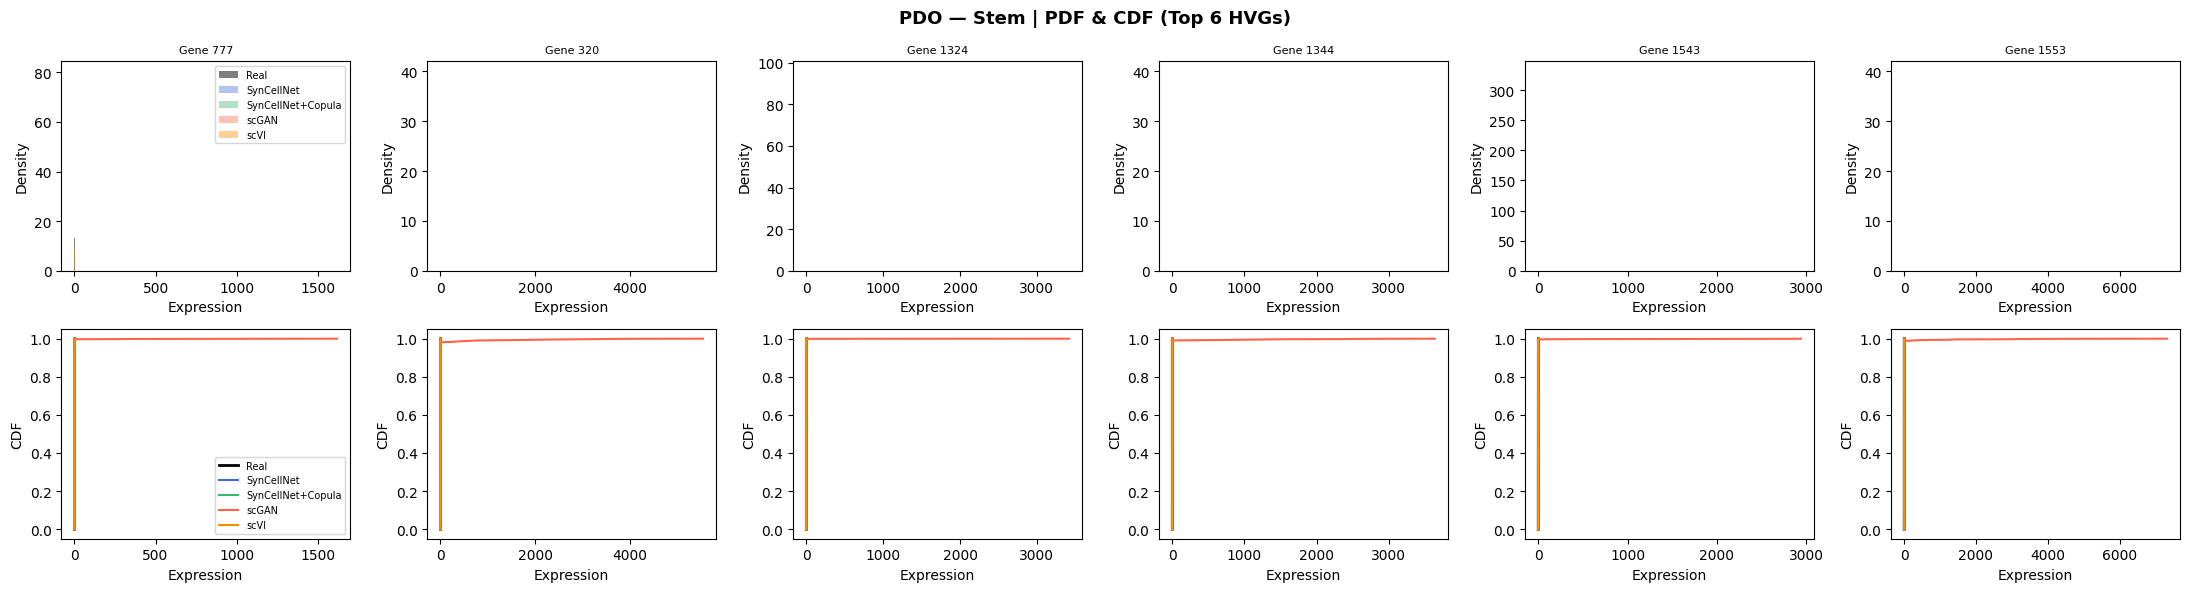

  Saved: pdf_cdf_PDO_Stem.png


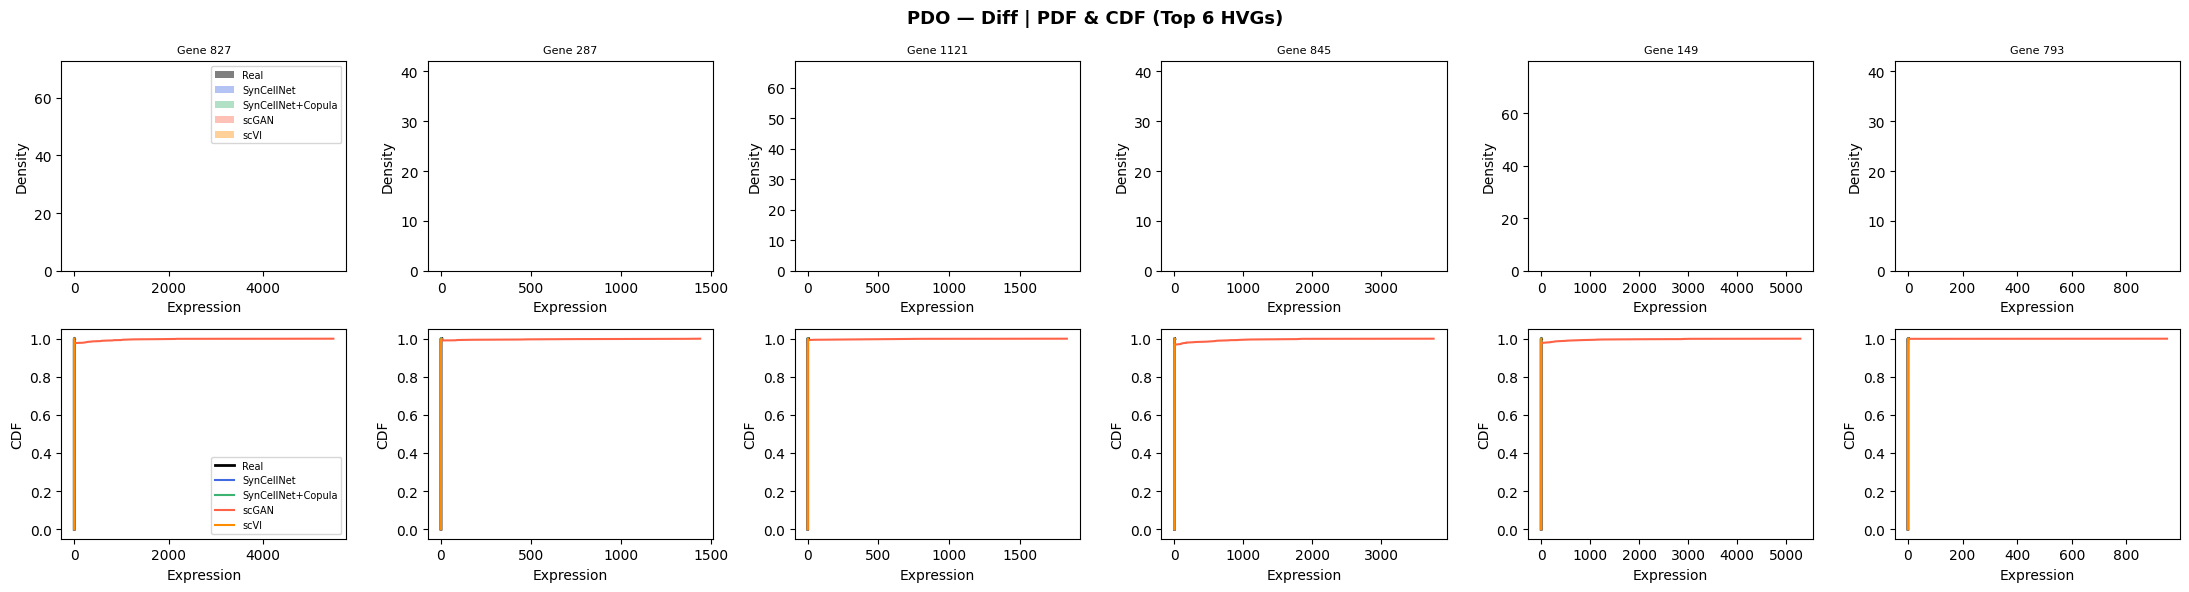

  Saved: pdf_cdf_PDO_Diff.png

GROUP 8: Visualization — PCA, t-SNE, UMAP
  Combined matrix: (14150, 1593)
  NaN after cleaning: 0  |  Inf: 0
  Running PCA...
  PCA variance explained (PC1+PC2): 5.3%
  Running t-SNE...
  Running UMAP...


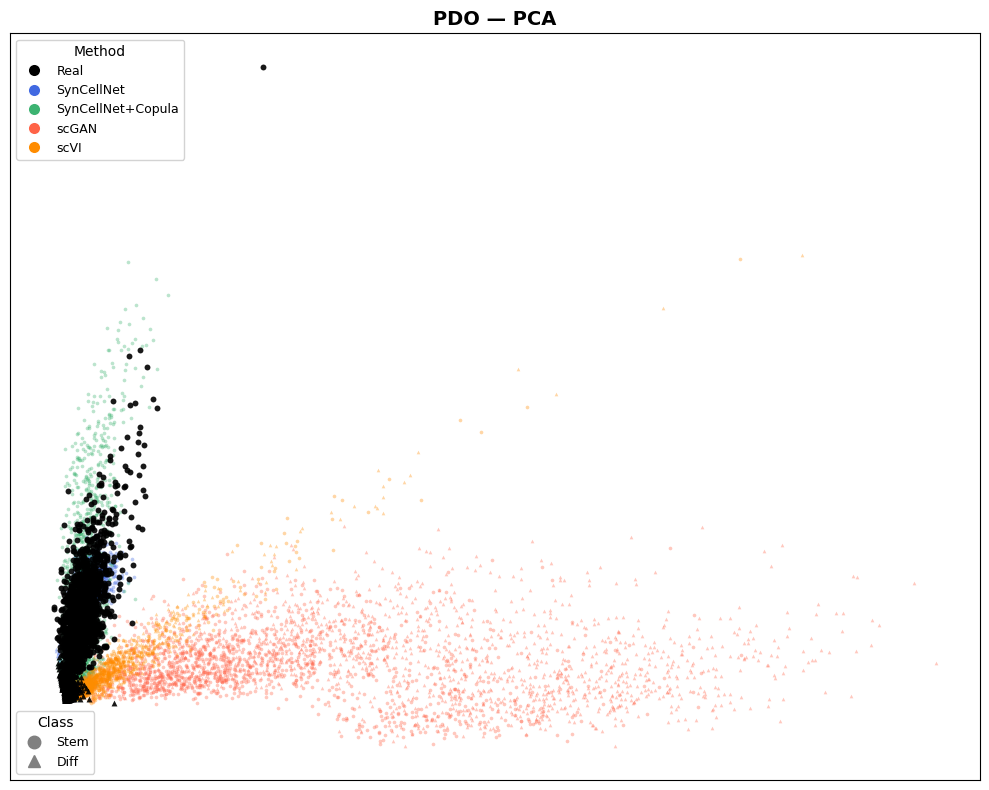

  Saved: pca_PDO.png


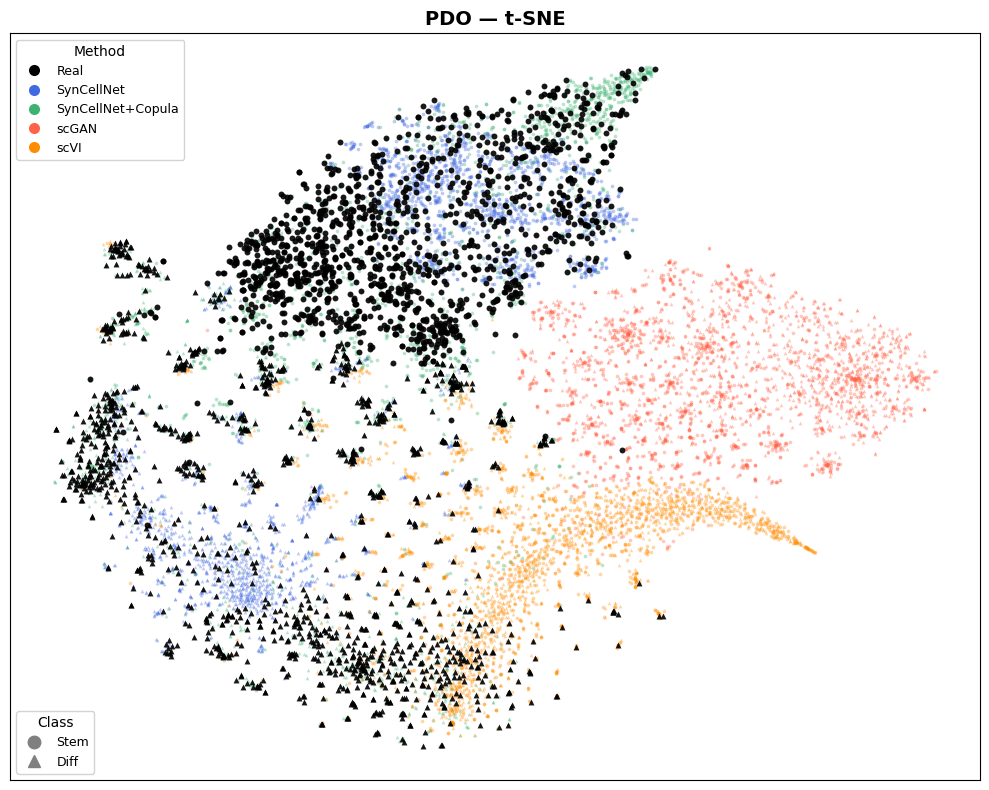

  Saved: tsne_PDO.png


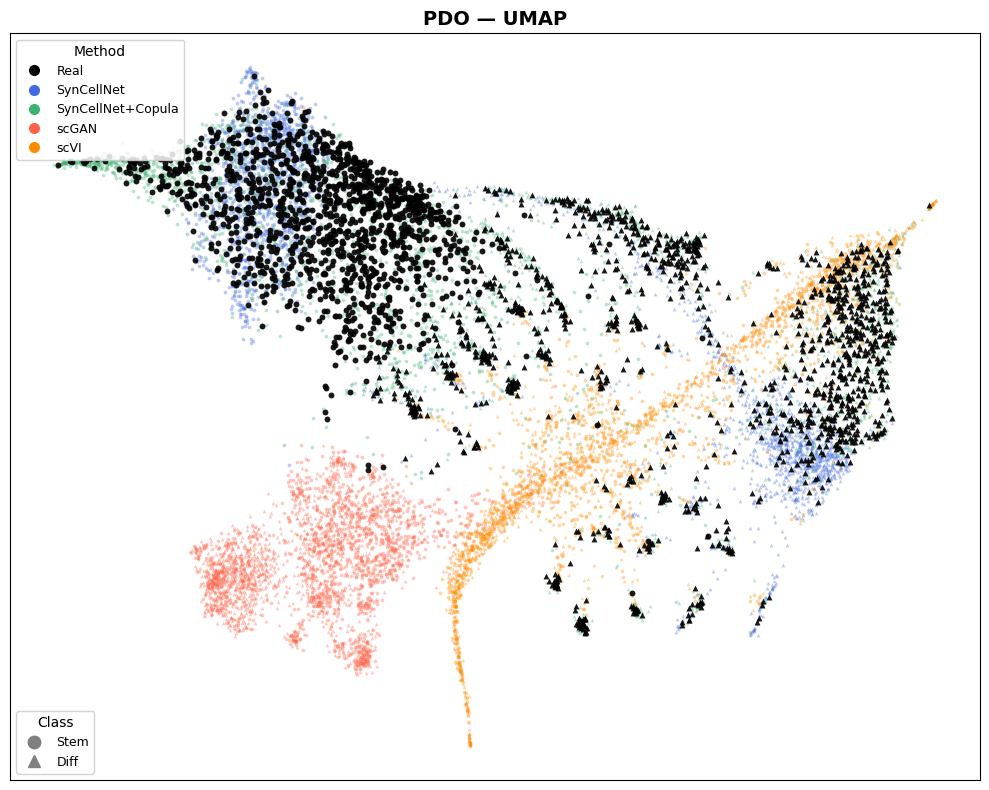

  Saved: umap_PDO.png

  Group 8 complete.

SUMMARY RESULTS TABLE
Saved to Drive: /content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset/metrics_results_PDO.csv
           Method Class  mean_corr  var_corr  cv_corr  det_corr frz_gene_corr  avg_KS lib_size_KS frz_cell_KS  cell_det_KS  cell_dist_KS  knn_occur_KS  ldf_KS  mean_var_corr_diff  mean_frz_corr_diff lib_frz_corr_diff gene_gene_corr    gene_gene_flag  marker_corr marker_flag  cell_cell_corr cell_cell_flag  avg_Wasserstein  avg_KDE_overlap      MMD  RF_AUC  pve_real  pve_synth  pve_diff  silhouette_real  silhouette_synth  silhouette_diff  n_DE_synth  DE_overlap  DE_precision  DE_recall  DE_F1
       SynCellNet  Stem     0.9646    0.4524   0.0659    0.4984           N/A  0.7231         N/A         N/A       1.0000         0.272         0.072   0.060              0.1530              0.7779               N/A        -0.0027                ok      -0.0378          ok          0.0286             ok           0.0763           0

In [2]:
# ============================================================
# Metrics Pipeline — scRNA-seq Synthetic Data Evaluation
# Google Colab | Python
# ============================================================

# ── Cell 1: Install ──────────────────────────────────────────
# !pip install -q umap-learn scikit-learn scipy seaborn matplotlib

# ── Cell 2: Imports ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance, spearmanr
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import umap
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

# ── Cell 3: Configuration ────────────────────────────────────
DATASET = 'PDO'   # 'PBMC' or 'PDO'

BASE = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work'

PATHS = {
    'PBMC': {
        'real': {
            'B':    BASE + '/Dataset/Real PBMC dataset/b_Class_dataset.csv',
            'Mono': BASE + '/Dataset/Real PBMC dataset/mono_Class_dataset.csv',
        },
        'SynCellNet': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/new_recovered_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/new_recovered_mono_expression.csv',
        },
        'SynCellNet+Copula': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/copula_recovered_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/copula_recovered_mono_expression.csv',
        },
        'scGAN': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/scGAN/PBMC/scgan_synthetic_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/scGAN/PBMC/scgan_synthetic_mono_expression.csv',
        },
        'scVI': {
            'B':    BASE + '/Dataset/Synthetic PBMC dataset/scVI/PBMC/scvi_synthetic_b_expression.csv',
            'Mono': BASE + '/Dataset/Synthetic PBMC dataset/scVI/PBMC/scvi_synthetic_mono_expression.csv',
        },
    },
    'PDO': {
        'real': {
            'Stem': BASE + '/Dataset/Real PDO/3. Stem_High_Raw_Finalized.csv',
            'Diff': BASE + '/Dataset/Real PDO/3. Differential_Low_Raw_Finalized.csv',
        },
        'SynCellNet': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/new_recovered_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/new_recovered_low_expression.csv',
        },
        'SynCellNet+Copula': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/copula_recovered_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/copula_recovered_low_expression.csv',
        },
        'scGAN': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/scGAN/PDO/scgan_synthetic_stem_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/scGAN/PDO/scgan_synthetic_diff_low_expression.csv',
        },
        'scVI': {
            'Stem': BASE + '/Dataset/Synthetic PDO dataset/scVI/PDO/scvi_synthetic_stem_high_expression.csv',
            'Diff': BASE + '/Dataset/Synthetic PDO dataset/scVI/PDO/scvi_synthetic_diff_low_expression.csv',
        },
    }
}

# Methods that skip library-size based metrics
SKIP_LIBSIZE = {'SynCellNet', 'scGAN'}
# Methods that skip fraction-zero metrics
SKIP_ZEROS   = {'SynCellNet'}

METHODS  = ['SynCellNet', 'SynCellNet+Copula', 'scGAN', 'scVI']
CLASSES  = list(PATHS[DATASET]['real'].keys())
SEED     = 42

print(f'Dataset  : {DATASET}')
print(f'Classes  : {CLASSES}')
print(f'Methods  : {METHODS}')

# ── Cell 4: Load Data ─────────────────────────────────────────
def load_csv(path):
    return pd.read_csv(path, header=None).values.astype(np.float32)

def align_genes(A, B):
    """Trim both arrays to same gene count (handles scGAN PDO 1593 vs 1600)."""
    n = min(A.shape[1], B.shape[1])
    return A[:, :n], B[:, :n]

data = {}
print(f'\nLoading {DATASET} data...')
for split in ['real'] + METHODS:
    data[split] = {}
    for cls in CLASSES:
        data[split][cls] = load_csv(PATHS[DATASET][split][cls])
        print(f'  {split:12s} {cls}: {data[split][cls].shape}')

# ── Cell 5: Utility Functions ─────────────────────────────────
def log1p_norm(X):
    return np.log1p(X)

def top_hvg_indices(X, n=500):
    """Return indices of top n highly variable genes by CV."""
    means = X.mean(axis=0)
    stds  = X.std(axis=0)
    cv    = np.where(means > 0, stds / means, 0)
    return np.argsort(cv)[::-1][:n]

def marker_gene_indices(X_class0, X_class1, n=30):
    """Top n DE genes by fold change between two classes."""
    eps = 1e-8
    fc  = np.abs(np.log2(X_class0.mean(0) + eps) - np.log2(X_class1.mean(0) + eps))
    return np.argsort(fc)[::-1][:n]

def to_pca(real, synth, n_pcs=50, seed=SEED):
    """
    Log1p + clip negatives, fit PCA on pooled data, return (r_pca, s_pca).
    Safe for SynCellNet floats (negative values clipped to 0 before log1p).
    """
    log_r = np.nan_to_num(np.log1p(np.clip(real,  0, None)), nan=0., posinf=0., neginf=0.)
    log_s = np.nan_to_num(np.log1p(np.clip(synth, 0, None)), nan=0., posinf=0., neginf=0.)
    n_comp = min(n_pcs, log_r.shape[1], log_r.shape[0] - 1, log_s.shape[0] - 1)
    pca    = PCA(n_components=n_comp, random_state=seed)
    pca.fit(np.vstack([log_r, log_s]))
    return pca.transform(log_r), pca.transform(log_s)

# ── Cell 6: Group 1 — Gene-level Distribution ─────────────────
print('\n' + '='*60)
print('GROUP 1: Gene-level Distribution')
print('='*60)

g1_results = {}

for method in METHODS:
    g1_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        mean_r = real.mean(0);  mean_s = synth.mean(0)
        var_r  = real.var(0);   var_s  = synth.var(0)
        eps    = 1e-8
        cv_r   = np.where(mean_r > 0, real.std(0)/mean_r, 0)
        cv_s   = np.where(mean_s > 0, synth.std(0)/mean_s, 0)
        det_r  = (real > 0).mean(0);  det_s = (synth > 0).mean(0)
        frz_r  = (real == 0).mean(0); frz_s = (synth == 0).mean(0)

        ks_mean  = np.mean([ks_2samp(real[:,g], synth[:,g]).statistic
                            for g in range(real.shape[1])])
        r_mean, _   = stats.pearsonr(mean_r, mean_s)
        r_var,  _   = stats.pearsonr(var_r,  var_s)
        r_cv,   _   = stats.pearsonr(cv_r,   cv_s)
        r_det,  _   = stats.pearsonr(det_r,  det_s)

        if method in SKIP_ZEROS:
            r_frz = np.nan
        else:
            r_frz, _ = stats.pearsonr(frz_r, frz_s)

        g1_results[method][cls] = {
            'mean_corr'    : round(r_mean, 4),
            'var_corr'     : round(r_var,  4),
            'cv_corr'      : round(r_cv,   4),
            'det_corr'     : round(r_det,  4),
            'frz_gene_corr': round(r_frz, 4) if not np.isnan(r_frz) else 'N/A',
            'avg_KS'       : round(ks_mean, 4),
        }
        print(f'  {method:12s} {cls}: mean_corr={r_mean:.4f}  var_corr={r_var:.4f}  '
              f'cv_corr={r_cv:.4f}  det_corr={r_det:.4f}  KS={ks_mean:.4f}')

# ── Cell 7: Group 2 — Cell-level Distribution ─────────────────
# Includes the 3 metrics required by Crowell et al. that were previously missing:
#   • cell_dist_KS  — KS distance between mean-kNN-distance distributions (PCA space)
#   • knn_occur_KS  — KS distance between kNN occurrence-count distributions
#   • ldf_KS        — KS distance between Local Density Factor distributions
# ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('GROUP 2: Cell-level Distribution')
print('='*60)

K_NEIGHBORS = 10   # k for all kNN-based cell metrics
N_SAMPLE_CELL = 500  # max cells to subsample for expensive cell metrics

def _subsample(X, n, seed=SEED):
    np.random.seed(seed)
    idx = np.random.choice(len(X), min(n, len(X)), replace=False)
    return X[idx]

def compute_cell_dist_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between distributions of mean Euclidean distance to k nearest
    neighbours in PCA space.  Captures whether the local neighbourhood
    density of the synthetic cells matches the real data.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def mean_knn_dist(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        dists, _ = nbrs.kneighbors(X)
        return dists[:, 1:].mean(axis=1)   # exclude self (col 0)

    return ks_2samp(mean_knn_dist(r_sub, k), mean_knn_dist(s_sub, k)).statistic


def compute_knn_occur_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between kNN occurrence-count distributions.
    Counts how many times each cell is selected as a nearest neighbour.
    Real data typically has a heavy-tailed distribution (a few 'hub' cells
    are very popular neighbours).  Uniform occurrence → artificial structure.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def knn_counts(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        _, indices = nbrs.kneighbors(X)
        counts = np.bincount(indices[:, 1:].ravel(), minlength=len(X))
        return counts.astype(float)

    return ks_2samp(knn_counts(r_sub, k), knn_counts(s_sub, k)).statistic


def compute_ldf_ks(r_pca, s_pca, k=K_NEIGHBORS, n=N_SAMPLE_CELL):
    """
    KS stat between Local Density Factor (LDF) distributions.
    LDF_i = (mean dist of cell i to its k neighbours)
            / (mean of [mean dist of each neighbour to ITS k neighbours])
    LDF > 1 → cell is in a sparser region than its neighbours (outlier).
    LDF < 1 → denser region.
    Mirrors the ldfDiff metric from CellMixS (Lütge et al. 2021) used in
    the Crowell et al. benchmark.
    """
    r_sub = _subsample(r_pca, n)
    s_sub = _subsample(s_pca, n)

    def ldf(X, k):
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(X)
        dists, indices = nbrs.kneighbors(X)
        avg_d = dists[:, 1:].mean(axis=1)          # avg dist to k neighbours
        # avg dist of each neighbour to ITS k neighbours
        neigh_avg_d = np.array([
            avg_d[indices[i, 1:]].mean() for i in range(len(X))
        ])
        return avg_d / (neigh_avg_d + 1e-10)

    return ks_2samp(ldf(r_sub, k), ldf(s_sub, k)).statistic


g2_results = {}

for method in METHODS:
    g2_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        # ── Original cell-level metrics ───────────────────────
        lib_r  = real.sum(1);  lib_s  = synth.sum(1)
        frz_r  = (real == 0).mean(1); frz_s  = (synth == 0).mean(1)
        det_r  = (real > 0).mean(1);  det_s  = (synth > 0).mean(1)

        if method in SKIP_LIBSIZE:
            ks_lib = np.nan
            r_lib  = np.nan
        else:
            ks_lib = ks_2samp(lib_r, lib_s).statistic
            r_lib, _ = stats.pearsonr(
                np.histogram(lib_r, bins=50)[0].astype(float),
                np.histogram(lib_s, bins=50)[0].astype(float))

        if method in SKIP_ZEROS:
            ks_frz = np.nan
        else:
            ks_frz = ks_2samp(frz_r, frz_s).statistic

        ks_det = ks_2samp(det_r, det_s).statistic

        # ── NEW: PCA-based cell-level metrics (Crowell et al.) ─
        r_pca, s_pca = to_pca(real, synth, n_pcs=50)

        cell_dist_ks = compute_cell_dist_ks(r_pca, s_pca)
        knn_occur_ks = compute_knn_occur_ks(r_pca, s_pca)
        ldf_ks       = compute_ldf_ks(r_pca, s_pca)

        g2_results[method][cls] = {
            'lib_size_KS'  : round(ks_lib, 4)       if not np.isnan(ks_lib) else 'N/A',
            'frz_cell_KS'  : round(ks_frz, 4)       if not np.isnan(ks_frz) else 'N/A',
            'cell_det_KS'  : round(ks_det, 4),
            # --- NEW ---
            'cell_dist_KS' : round(cell_dist_ks, 4),   # lower = better
            'knn_occur_KS' : round(knn_occur_ks, 4),   # lower = better
            'ldf_KS'       : round(ldf_ks, 4),         # lower = better
        }
        print(f'  {method:12s} {cls}: '
              f'lib_KS={ks_lib:.4f}  frz_KS={ks_frz:.4f}  det_KS={ks_det:.4f}  '
              f'cell_dist_KS={cell_dist_ks:.4f}  knn_occur_KS={knn_occur_ks:.4f}  '
              f'ldf_KS={ldf_ks:.4f}')

# ── Cell 8: Group 3 — Bivariate Relationships ─────────────────
print('\n' + '='*60)
print('GROUP 3: Bivariate Relationships')
print('='*60)

g3_results = {}

for method in METHODS:
    g3_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])
        eps = 1e-8

        mean_r = real.mean(0);  mean_s = synth.mean(0)
        var_r  = real.var(0);   var_s  = synth.var(0)
        frz_r  = (real == 0).mean(0); frz_s = (synth == 0).mean(0)

        mv_r, _ = stats.pearsonr(mean_r, var_r)
        mv_s, _ = stats.pearsonr(mean_s, var_s)
        mv_diff = abs(mv_r - mv_s)

        mz_r, _ = stats.pearsonr(mean_r, frz_r)
        mz_s, _ = stats.pearsonr(mean_s, frz_s)
        mz_diff = abs(mz_r - mz_s)

        if method in SKIP_LIBSIZE:
            lz_diff = np.nan
        else:
            lib_r = real.sum(1);  lib_s = synth.sum(1)
            lz_r, _ = stats.pearsonr(lib_r, (real == 0).mean(1))
            lz_s, _ = stats.pearsonr(lib_s, (synth == 0).mean(1))
            lz_diff = abs(lz_r - lz_s)

        g3_results[method][cls] = {
            'mean_var_corr_diff' : round(mv_diff, 4),
            'mean_frz_corr_diff' : round(mz_diff, 4),
            'lib_frz_corr_diff'  : round(lz_diff, 4) if not np.isnan(lz_diff) else 'N/A',
        }
        print(f'  {method:12s} {cls}: MeanVar_diff={mv_diff:.4f}  MeanFrz_diff={mz_diff:.4f}  '
              f'LibFrz_diff={lz_diff:.4f}')

# ── Cell 9: Group 4 — Correlation Structure ───────────────────
print('\n' + '='*60)
print('GROUP 4: Correlation Structure')
print('='*60)

g4_results = {}

real_c0 = data['real'][CLASSES[0]]
real_c1 = data['real'][CLASSES[1]]
marker_idx = marker_gene_indices(real_c0, real_c1, n=30)

def safe_pearsonr(x, y, label=''):
    # Remove NaN pairs first (from degenerate genes/cells in corrcoef)
    mask = ~(np.isnan(x) | np.isnan(y))
    n_valid = mask.sum()
    n_total = len(x)

    if n_valid < 10:
        print(f'    [WARN] {label}: only {n_valid}/{n_total} valid pairs → reporting N/A')
        return np.nan, 'insufficient_data'

    if n_valid < n_total:
        print(f'    [INFO] {label}: {n_total - n_valid} NaN pairs removed '
              f'({(n_total-n_valid)/n_total*100:.1f}%), using {n_valid} pairs')

    x, y = x[mask], y[mask]

    std_x, std_y = x.std(), y.std()

    if std_x < 1e-8 and std_y < 1e-8:
        flag = 'both_flat'
        val  = 1.0 if np.allclose(x, y) else np.nan
    elif std_x < 1e-8:
        flag = 'real_flat'
        val  = np.nan
    elif std_y < 1e-8:
        if np.allclose(x, y, atol=1e-6):
            flag = 'perfect'
            val  = 1.0
        else:
            flag = 'synth_flat'
            val  = np.nan
    else:
        r, _ = stats.pearsonr(x, y)
        flag = 'ok'
        val  = r

    if flag != 'ok':
        print(f'    [WARN] {label}: flag={flag}  '
              f'std_real={std_x:.6f}  std_synth={std_y:.6f}')
    return val, flag

for method in METHODS:
    g4_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        # ── Gene-gene correlation ──────────────────────────────
        hvg_idx = top_hvg_indices(real, n=300)
        hvg_idx = hvg_idx[hvg_idx < real.shape[1]]

        r_hvg = np.corrcoef(real[:, hvg_idx].T)
        s_hvg = np.corrcoef(synth[:, hvg_idx].T)
        triu  = np.triu_indices(len(hvg_idx), k=1)

        gene_gene_corr, gg_flag = safe_pearsonr(
            r_hvg[triu], s_hvg[triu],
            label=f'{method} {cls} gene-gene'
        )

        # ── Marker gene correlation ────────────────────────────
        mk_idx = marker_idx[marker_idx < real.shape[1]]
        r_mk = np.corrcoef(real[:, mk_idx].T)
        s_mk = np.corrcoef(synth[:, mk_idx].T)
        triu_mk = np.triu_indices(len(mk_idx), k=1)

        marker_corr, mk_flag = safe_pearsonr(
            r_mk[triu_mk], s_mk[triu_mk],
            label=f'{method} {cls} marker'
        )

        # ── Cell-cell correlation ──────────────────────────────
        np.random.seed(SEED)
        n_cells = min(len(real), len(synth), 300)
        idx   = np.random.choice(min(len(real), len(synth)), n_cells, replace=False)
        r_cc  = np.corrcoef(real[idx])
        s_cc  = np.corrcoef(synth[idx])
        triu_cc = np.triu_indices(n_cells, k=1)

        cell_corr, cc_flag = safe_pearsonr(
            r_cc[triu_cc], s_cc[triu_cc],
            label=f'{method} {cls} cell-cell'
        )

        g4_results[method][cls] = {
            'gene_gene_corr' : round(gene_gene_corr, 4) if not np.isnan(gene_gene_corr) else 'N/A',
            'gene_gene_flag' : gg_flag,
            'marker_corr'    : round(marker_corr,    4) if not np.isnan(marker_corr)    else 'N/A',
            'marker_flag'    : mk_flag,
            'cell_cell_corr' : round(cell_corr,      4) if not np.isnan(cell_corr)      else 'N/A',
            'cell_cell_flag' : cc_flag,
        }

        print(f'  {method:20s} {cls}: '
              f'gene-gene={gene_gene_corr:.4f}({gg_flag})  '
              f'marker={marker_corr:.4f}({mk_flag})  '
              f'cell-cell={cell_corr:.4f}({cc_flag})'
              if not np.isnan(gene_gene_corr) and not np.isnan(marker_corr) and not np.isnan(cell_corr)
              else f'  {method:20s} {cls}: '
                   f'gene-gene={gene_gene_corr}({gg_flag})  '
                   f'marker={marker_corr}({mk_flag})  '
                   f'cell-cell={cell_corr}({cc_flag})')

# ── Cell 10: Group 5 — Distributional Similarity ──────────────
print('\n' + '='*60)
print('GROUP 5: Distributional Similarity')
print('='*60)

g5_results = {}

def kde_overlap(x, y, n_points=200):
    """KDE-based overlap: 1 = identical, 0 = no overlap."""
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    grid = np.linspace(mn, mx, n_points)
    kde_x = stats.gaussian_kde(x)(grid)
    kde_y = stats.gaussian_kde(y)(grid)
    return float(np.sum(np.sqrt(kde_x * kde_y)) * (mx - mn) / n_points)

for method in METHODS:
    g5_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])
        n_genes = real.shape[1]

        ks_scores, wass_scores, kde_scores = [], [], []

        hvg_idx = top_hvg_indices(real, n=200)
        hvg_idx = hvg_idx[hvg_idx < n_genes]

        for g in range(n_genes):
            r_g = real[:, g]; s_g = synth[:, g]
            ks_scores.append(ks_2samp(r_g, s_g).statistic)
            wass_scores.append(wasserstein_distance(r_g, s_g))

        for g in hvg_idx:
            r_g = real[:, g]; s_g = synth[:, g]
            if r_g.std() > 0 and s_g.std() > 0:
                kde_scores.append(kde_overlap(r_g, s_g))

        g5_results[method][cls] = {
            'avg_KS'          : round(np.mean(ks_scores),   4),
            'avg_Wasserstein' : round(np.mean(wass_scores), 4),
            'avg_KDE_overlap' : round(np.mean(kde_scores),  4),
        }
        print(f'  {method:12s} {cls}: KS={np.mean(ks_scores):.4f}  '
              f'Wasserstein={np.mean(wass_scores):.4f}  KDE_overlap={np.mean(kde_scores):.4f}')

# ── Cell 11: Group 6 — Global Structural ──────────────────────
# Includes 2 metrics required by Crowell et al. that were previously missing:
#   • pve_diff       — |PVE_real − PVE_synth|  (% variance explained by class)
#   • silhouette_diff — |silhouette_real − silhouette_synth|
# Both measure whether the global class structure is faithfully preserved.
# ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('GROUP 6: Global Structural')
print('='*60)

def compute_mmd(X, Y, sigmas=(0.1, 0.5, 1.0, 2.0, 5.0)):
    """MMD with RBF kernel sum. Uses PCA-reduced space (50 PCs)."""
    X_c = np.nan_to_num(np.log1p(np.clip(X, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)
    Y_c = np.nan_to_num(np.log1p(np.clip(Y, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)

    n_comp = min(50, X_c.shape[1], X_c.shape[0], Y_c.shape[0])
    pca    = PCA(n_components=n_comp, random_state=SEED)
    Xr     = pca.fit_transform(np.vstack([X_c, Y_c]))
    X_pca  = Xr[:len(X_c)]
    Y_pca  = Xr[len(X_c):]

    def rbf_kernel(A, B, s):
        diff = A[:, None, :] - B[None, :, :]
        return np.exp(-np.sum(diff**2, axis=-1) / (2 * s**2))

    mmd2 = 0.0
    n, m = len(X_pca), len(Y_pca)
    for s in sigmas:
        Kxx = rbf_kernel(X_pca, X_pca, s)
        Kyy = rbf_kernel(Y_pca, Y_pca, s)
        Kxy = rbf_kernel(X_pca, Y_pca, s)
        mmd2 += ((Kxx.sum() - np.diag(Kxx).sum()) / (n*(n-1))
               + (Kyy.sum() - np.diag(Kyy).sum()) / (m*(m-1))
               - 2 * Kxy.mean())
    return float(mmd2)


def compute_rf_auc(X_real, X_synth, seed=42):
    """RF classifier AUC: how well can we distinguish real from synthetic."""
    Xr = np.nan_to_num(np.log1p(np.clip(X_real,  0, None)), nan=0.0, posinf=0.0, neginf=0.0)
    Xs = np.nan_to_num(np.log1p(np.clip(X_synth, 0, None)), nan=0.0, posinf=0.0, neginf=0.0)

    X = np.vstack([Xr, Xs])
    y = np.array([1]*len(Xr) + [0]*len(Xs))

    rf  = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    aucs = []
    for tr, te in skf.split(X, y):
        rf.fit(X[tr], y[tr])
        p = rf.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(aucs))


def compute_pve(real_c0, real_c1, synth_c0, synth_c1, n_pcs=50, seed=SEED):
    """
    Percent Variance Explained (PVE) by class label — Crowell et al. global summary.

    For each dataset (real / synthetic), stack both classes, project to PCA,
    then compute the fraction of per-PC variance attributable to the class label
    (SS_between / SS_total averaged across PCs).

    Returns:
        pve_real  : float  — PVE in real data
        pve_synth : float  — PVE in synthetic data
        pve_diff  : float  — |pve_real − pve_synth|  (lower = better)
    """
    def _pve(X0, X1):
        X   = np.nan_to_num(np.log1p(np.clip(np.vstack([X0, X1]), 0, None)))
        y   = np.array([0]*len(X0) + [1]*len(X1))
        n_comp = min(n_pcs, X.shape[1], X.shape[0] - 1)
        pca = PCA(n_components=n_comp, random_state=seed)
        Z   = pca.fit_transform(X)

        grand_mean = Z.mean(axis=0)
        n0, n1     = (y == 0).sum(), (y == 1).sum()
        mean_0     = Z[y == 0].mean(axis=0)
        mean_1     = Z[y == 1].mean(axis=0)

        SS_between = (n0 * (mean_0 - grand_mean)**2
                    + n1 * (mean_1 - grand_mean)**2)
        SS_total   = ((Z - grand_mean)**2).sum(axis=0)
        pve_per_pc = np.where(SS_total > 0, SS_between / SS_total, 0.0)
        return float(pve_per_pc.mean())

    pve_r = _pve(real_c0,  real_c1)
    pve_s = _pve(synth_c0, synth_c1)
    return pve_r, pve_s, abs(pve_r - pve_s)


def compute_silhouette(real_c0, real_c1, synth_c0, synth_c1,
                       n_pcs=50, n_sample=500, seed=SEED):
    """
    Silhouette width for class labels in PCA space — Crowell et al. global summary.

    Computed separately for real and synthetic (both classes pooled).
    A high silhouette in real data but low in synthetic → simulator
    collapses the class boundary.

    Returns:
        sil_real  : float  — silhouette in real data     (higher = clearer clusters)
        sil_synth : float  — silhouette in synthetic
        sil_diff  : float  — |sil_real − sil_synth|      (lower = better preserved)
    """
    def _sil(X0, X1):
        np.random.seed(seed)
        X   = np.nan_to_num(np.log1p(np.clip(np.vstack([X0, X1]), 0, None)))
        y   = np.array([0]*len(X0) + [1]*len(X1))
        idx = np.random.choice(len(X), min(n_sample, len(X)), replace=False)
        X_s, y_s = X[idx], y[idx]
        if len(np.unique(y_s)) < 2:
            return np.nan
        n_comp = min(n_pcs, X_s.shape[1], X_s.shape[0] - 1)
        Z = PCA(n_components=n_comp, random_state=seed).fit_transform(X_s)
        return float(silhouette_score(Z, y_s))

    sil_r = _sil(real_c0,  real_c1)
    sil_s = _sil(synth_c0, synth_c1)
    return sil_r, sil_s, abs(sil_r - sil_s)


g6_results = {}

real_c0_all = data['real'][CLASSES[0]]
real_c1_all = data['real'][CLASSES[1]]

for method in METHODS:
    g6_results[method] = {}
    for cls in CLASSES:
        real, synth = align_genes(data['real'][cls], data[method][cls])

        np.random.seed(SEED)
        r_idx = np.random.choice(len(real),  min(500, len(real)),  replace=False)
        s_idx = np.random.choice(len(synth), min(500, len(synth)), replace=False)

        mmd = compute_mmd(real[r_idx], synth[s_idx])
        auc = compute_rf_auc(real, synth)

        g6_results[method][cls] = {
            'MMD'    : round(mmd, 6),
            'RF_AUC' : round(auc, 4),
        }
        print(f'  {method:12s} {cls}: MMD={mmd:.6f}  RF_AUC={auc:.4f}')

    # ── NEW: PVE and Silhouette (computed across both classes jointly) ──
    # Align all four arrays to minimum gene count
    min_g = min(
        data['real'][CLASSES[0]].shape[1], data['real'][CLASSES[1]].shape[1],
        data[method][CLASSES[0]].shape[1], data[method][CLASSES[1]].shape[1]
    )
    rc0 = data['real'][CLASSES[0]][:, :min_g]
    rc1 = data['real'][CLASSES[1]][:, :min_g]
    sc0 = data[method][CLASSES[0]][:, :min_g]
    sc1 = data[method][CLASSES[1]][:, :min_g]

    pve_r, pve_s, pve_diff   = compute_pve(rc0, rc1, sc0, sc1)
    sil_r, sil_s, sil_diff   = compute_silhouette(rc0, rc1, sc0, sc1)

    # Store these at method level (not per-class — they use both classes)
    g6_results[method]['_global'] = {
        'pve_real'       : round(pve_r,    4),
        'pve_synth'      : round(pve_s,    4),
        'pve_diff'       : round(pve_diff, 4),   # lower = better
        'silhouette_real' : round(sil_r,   4),
        'silhouette_synth': round(sil_s,   4),
        'silhouette_diff' : round(sil_diff, 4),  # lower = better
    }
    print(f'  {method:12s} [global]: '
          f'PVE_real={pve_r:.4f}  PVE_synth={pve_s:.4f}  PVE_diff={pve_diff:.4f}  '
          f'Sil_real={sil_r:.4f}  Sil_synth={sil_s:.4f}  Sil_diff={sil_diff:.4f}')

# ── Cell 12: Group 7 — Biological Signal (DE Genes) ──────────
print('\n' + '='*60)
print('GROUP 7: Biological Signal Preservation (DE Genes)')
print('='*60)

def get_de_genes(X0, X1, alpha=0.05):
    n_genes = X0.shape[1]
    pvals   = []
    for g in range(n_genes):
        _, p = mannwhitneyu(X0[:, g], X1[:, g], alternative='two-sided')
        pvals.append(p)
    _, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')
    return pvals_adj < alpha

real_c0 = data['real'][CLASSES[0]]
real_c1 = data['real'][CLASSES[1]]

min_genes = min(data[m][c].shape[1] for m in METHODS for c in CLASSES)
real_c0_al = real_c0[:, :min_genes]
real_c1_al = real_c1[:, :min_genes]

print(f'  Computing DE genes in real data (n_genes={min_genes})...')
de_real    = get_de_genes(real_c0_al, real_c1_al)
n_de_real  = de_real.sum()
print(f'  Real DE genes: {n_de_real} / {min_genes} ({n_de_real/min_genes*100:.1f}%)')

g7_results = {}

for method in METHODS:
    synth_c0 = data[method][CLASSES[0]][:, :min_genes]
    synth_c1 = data[method][CLASSES[1]][:, :min_genes]

    de_synth   = get_de_genes(synth_c0, synth_c1)
    n_de_synth = de_synth.sum()

    overlap   = (de_real & de_synth).sum()
    precision = overlap / n_de_synth if n_de_synth > 0 else 0
    recall    = overlap / n_de_real  if n_de_real  > 0 else 0
    f1        = (2*precision*recall/(precision+recall)
                 if (precision+recall) > 0 else 0)

    g7_results[method] = {
        'n_DE_synth'   : int(n_de_synth),
        'DE_overlap'   : int(overlap),
        'DE_precision' : round(precision, 4),
        'DE_recall'    : round(recall,    4),
        'DE_F1'        : round(f1,        4),
    }
    print(f'  {method:12s}: DE_synth={n_de_synth}  overlap={overlap}  '
          f'precision={precision:.4f}  recall={recall:.4f}  F1={f1:.4f}')

# ── Cell 13: PDF / CDF Plots (per class, top 6 HVGs) ──────────
print('\n' + '='*60)
print('PDF / CDF Comparison (Top 6 HVGs)')
print('='*60)

METHOD_COLORS = {
    'SynCellNet'        : 'royalblue',
    'SynCellNet+Copula' : 'mediumseagreen',   # ← fixed
    'scGAN'             : 'tomato',
    'scVI'              : 'darkorange',
}

for cls in CLASSES:
    real    = data['real'][cls]
    hvg_idx = top_hvg_indices(real, n=6)

    fig, axes = plt.subplots(2, 6, figsize=(22, 6))
    fig.suptitle(f'{DATASET} — {cls} | PDF & CDF (Top 6 HVGs)', fontsize=13, fontweight='bold')

    for gi, gene in enumerate(hvg_idx):
        ax_pdf = axes[0, gi]
        ax_cdf = axes[1, gi]
        r_g    = real[:, gene]

        ax_pdf.hist(r_g, bins=40, alpha=0.5, color='black', label='Real', density=True)
        ax_cdf.plot(np.sort(r_g), np.linspace(0, 1, len(r_g)), color='black', label='Real', lw=2)

        for method in METHODS:
            synth, _ = align_genes(data[method][cls], real)
            if gene >= synth.shape[1]: continue
            s_g  = synth[:, gene]
            col  = METHOD_COLORS[method]
            ax_pdf.hist(s_g, bins=40, alpha=0.4, color=col, label=method, density=True)
            ax_cdf.plot(np.sort(s_g), np.linspace(0, 1, len(s_g)), color=col, label=method, lw=1.5)

        ax_pdf.set_title(f'Gene {gene}', fontsize=8)
        ax_pdf.set_xlabel('Expression'); ax_pdf.set_ylabel('Density')
        ax_cdf.set_xlabel('Expression'); ax_cdf.set_ylabel('CDF')
        if gi == 0:
            ax_pdf.legend(fontsize=7)
            ax_cdf.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'pdf_cdf_{DATASET}_{cls}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: pdf_cdf_{DATASET}_{cls}.png')

# ── Cell 14: Group 8 — Visualization (PCA, t-SNE, UMAP) ───────
print('\n' + '='*60)
print('GROUP 8: Visualization — PCA, t-SNE, UMAP')
print('='*60)

from matplotlib.lines import Line2D

def build_combined(dataset, methods, classes, min_g):
    Xs, labels_m, labels_c = [], [], []
    for cls in classes:
        X = dataset['real'][cls][:, :min_g]
        Xs.append(X)
        labels_m.extend(['Real'] * len(X))
        labels_c.extend([cls]   * len(X))
    for method in methods:
        for cls in classes:
            X = dataset[method][cls][:, :min_g]
            Xs.append(X)
            labels_m.extend([method] * len(X))
            labels_c.extend([cls]    * len(X))
    return np.vstack(Xs), np.array(labels_m), np.array(labels_c)

min_g = min(data[m][c].shape[1] for m in METHODS for c in CLASSES)
X_all, lbl_method, lbl_class = build_combined(data, METHODS, CLASSES, min_g)
print(f'  Combined matrix: {X_all.shape}')

X_log = np.log1p(np.clip(X_all, a_min=0, a_max=None))
X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
print(f'  NaN after cleaning: {np.isnan(X_log).sum()}  |  '
      f'Inf: {np.isinf(X_log).sum()}')

print('  Running PCA...')
pca     = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_log)
X_pca2  = X_pca50[:, :2]
print(f'  PCA variance explained (PC1+PC2): '
      f'{pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

print('  Running t-SNE...')
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=30,
              n_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca50)

print('  Running UMAP...')
reducer = umap.UMAP(n_components=2, random_state=SEED,
                    n_neighbors=30, min_dist=0.3)
X_umap  = reducer.fit_transform(X_pca50)

METHOD_COLORS_VIZ = {
    'Real'              : 'black',
    'SynCellNet'        : 'royalblue',
    'SynCellNet+Copula' : 'mediumseagreen',   # ← fixed
    'scGAN'             : 'tomato',
    'scVI'              : 'darkorange',
}
CLASS_MARKERS = {CLASSES[0]: 'o', CLASSES[1]: '^'}

def plot_embedding(X_emb, lbl_m, lbl_c, title, fname):
    fig, ax = plt.subplots(figsize=(10, 8))

    for method in METHODS + ['Real']:
        for cls in CLASSES:
            mask  = (lbl_m == method) & (lbl_c == cls)
            if mask.sum() == 0: continue
            alpha  = 0.9 if method == 'Real' else 0.35
            size   = 18  if method == 'Real' else 7
            zorder = 5   if method == 'Real' else 2
            ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                       c=METHOD_COLORS_VIZ[method],
                       marker=CLASS_MARKERS[cls],
                       alpha=alpha, s=size, zorder=zorder,
                       linewidths=0)

    method_handles = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=METHOD_COLORS_VIZ[m],
               markersize=9, label=m)
        for m in ['Real'] + METHODS
    ]
    class_handles = [
        Line2D([0],[0], marker=CLASS_MARKERS[cl],
               color='gray', markersize=9, label=cl, linestyle='None')
        for cl in CLASSES
    ]
    legend1 = ax.legend(handles=method_handles, loc='upper left',
                        fontsize=9, title='Method', framealpha=0.85)
    ax.add_artist(legend1)
    ax.legend(handles=class_handles, loc='lower left',
              fontsize=9, title='Class', framealpha=0.85)

    ax.set_title(f'{DATASET} — {title}', fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')

plot_embedding(X_pca2,  lbl_method, lbl_class, 'PCA',   f'pca_{DATASET}.png')
plot_embedding(X_tsne,  lbl_method, lbl_class, 't-SNE', f'tsne_{DATASET}.png')
plot_embedding(X_umap,  lbl_method, lbl_class, 'UMAP',  f'umap_{DATASET}.png')
print('\n  Group 8 complete.')

# ── Cell 15: Summary Results Table ────────────────────────────
print('\n' + '='*60)
print('SUMMARY RESULTS TABLE')
print('='*60)

rows = []
for method in METHODS:
    for cls in CLASSES:
        row = {'Method': method, 'Class': cls}
        row.update(g1_results[method][cls])
        row.update(g2_results[method][cls])
        row.update(g3_results[method][cls])
        row.update(g4_results[method][cls])
        row.update(g5_results[method][cls])
        row.update(g6_results[method][cls])
        row.update(g6_results[method].get('_global', {}))
        row.update(g7_results[method])
        rows.append(row)

df_results = pd.DataFrame(rows)  # ← was missing

DST = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet work/Dataset'
save_path = os.path.join(DST, f'metrics_results_{DATASET}.csv')
df_results.to_csv(save_path, index=False)
print(f'Saved to Drive: {save_path}')  # ← fixed

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df_results.to_string(index=False))

Log Fold PDO

In [3]:
# ── Cell 12b: Log Fold Change Correlation ─────────────────────
print('\n' + '='*60)
print('GROUP 7b: Log Fold Change Correlation (Real vs Synthetic)')
print('='*60)

def compute_lfc(X0, X1, eps=1e-8):
    """Log2 fold change: class0 vs class1, per gene."""
    return np.log2(X0.mean(0) + eps) - np.log2(X1.mean(0) + eps)

real_c0 = data['real'][CLASSES[0]][:, :min_genes]
real_c1 = data['real'][CLASSES[1]][:, :min_genes]
lfc_real = compute_lfc(real_c0, real_c1)

g7b_results = {}

for method in METHODS:
    synth_c0 = data[method][CLASSES[0]][:, :min_genes]
    synth_c1 = data[method][CLASSES[1]][:, :min_genes]
    lfc_synth = compute_lfc(synth_c0, synth_c1)

    # Pearson on all genes
    r_all, p_all = stats.pearsonr(lfc_real, lfc_synth)

    # Pearson restricted to real DE genes only
    de_mask = de_real  # boolean array from Cell 12
    r_de, p_de = stats.pearsonr(lfc_real[de_mask], lfc_synth[de_mask])

    # Spearman on DE genes
    rho_de, _ = spearmanr(lfc_real[de_mask], lfc_synth[de_mask])

    g7b_results[method] = {
        'LFC_pearson_all'  : round(r_all,  4),
        'LFC_pearson_DE'   : round(r_de,   4),
        'LFC_spearman_DE'  : round(rho_de, 4),
    }
    print(f'  {method:20s}: '
          f'LFC_pearson_all={r_all:.4f}  '
          f'LFC_pearson_DE={r_de:.4f}  '
          f'LFC_spearman_DE={rho_de:.4f}')


GROUP 7b: Log Fold Change Correlation (Real vs Synthetic)
  SynCellNet          : LFC_pearson_all=nan  LFC_pearson_DE=nan  LFC_spearman_DE=nan
  SynCellNet+Copula   : LFC_pearson_all=0.3081  LFC_pearson_DE=0.4303  LFC_spearman_DE=0.6465
  scGAN               : LFC_pearson_all=0.0549  LFC_pearson_DE=0.0255  LFC_spearman_DE=0.0421
  scVI                : LFC_pearson_all=-0.0228  LFC_pearson_DE=-0.0029  LFC_spearman_DE=0.0030
